## **NIE MA SENSU POKAZYWAC POJEDYNCZEJ ESTYMACJI - TO NIC NIE MOWI - ZOSTAWIC SAME MONTE CARLO I REAL DATA - DLA 1D I DLA 2D**

# Modelling the Health Condition of Machines Using Sub-Gaussian Distributions

**Course:** Computer Modelling and Simulation of Stochastic Processes  
**Authors:** Mateusz Ćwiek, Rafał Głodek, Hubert Nowak, Romain Steffein, Kacper Ujma

The notebook is organized as a project report. It first introduces the modelling assumptions, then presents the one-dimensional model, its simulation and estimation pipeline, extends the same idea to the two-dimensional sub-Gaussian model, and finally applies the pipeline to the IMS Bearing Dataset. The Monte Carlo parts are intentionally left as executable cells with the parameters used in the study; they may take longer to recompute than the single-trajectory examples.

In [1]:
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import simulation1d
import estimation1d
import simulation2d
import estimation2d
import plotting_utils
import monte_carlo_utils

importlib.reload(simulation1d)
importlib.reload(estimation1d)
importlib.reload(simulation2d)
importlib.reload(estimation2d)
importlib.reload(plotting_utils)
importlib.reload(monte_carlo_utils)

from simulation1d import simulate_1d_model
from estimation1d import estimate_1d_model, summarize_1d_estimation, estimate_1d_model_fixed_ar_order
from simulation2d import simulate_2d_model
from estimation2d import estimate_2d_model_fixed_var1, summarize_2d_estimation
from monte_carlo_utils import (
    run_mc_1d_for_alpha,
    run_mc_2d_for_alpha,
    add_scale_adjusted_sigma,
    scale_ratio_2d_summary,
    adjusted_sigma_summary,
)
from plotting_utils import (
    add_regime_annotations,
    plot_2d_acf_ccf_diagnostics,
    plot_mc_1d_estimation_results,
    plot_mc_1d_median_band,
    plot_mc_2d_part1,
    plot_mc_2d_part2,
    plot_real_acf_ccf_diagnostics,
    plot_representative_acf_1d,
    plot_sigma_boxplots_adjusted,
)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Introduction and Motivation

Machine condition monitoring is the continuous observation of a machine during operation using signals from vibration sensors, acoustic sensors or other diagnostic measurements. The practical goal is to detect deterioration early enough to support predictive maintenance decisions: replacing or inspecting a component before a failure causes downtime, secondary damage or safety risk.

A health index (HI) is a lower-dimensional diagnostic signal constructed from raw measurements. Instead of modelling millions of vibration samples directly, the project models a time series whose level and variability summarize machine condition. The expected degradation path is divided into regimes: a **normal / healthy state**, a **warning / degradation state**, and an **alarm / critical state**. In synthetic data these regimes are controlled by predefined change points; in real data they must be detected or taken from a documented reference analysis.

Stochastic modelling is needed because degradation signals are not deterministic curves. Even after trend extraction, they contain random fluctuations, temporal dependence and occasional impulses. The seminar materials and reference thesis motivate alpha-stable and sub-Gaussian models because they can represent heavy-tailed behaviour that is not captured well by purely Gaussian noise.


## Mathematical Background

The observed health-index signal is decomposed into a deterministic part and a random part:

$$
S(t)=R(t)+T(t),
$$

where $T(t)$ is the degradation trend and $R(t)$ contains stochastic fluctuations around this trend. In the one-dimensional model the random component is further decomposed as

$$
R(t)=SC(t)R2(t),
$$

where $SC(t)$ is a time-varying scale function and $R2(t)$ is a normalized stationary process. This separates three effects: the slowly changing level of degradation, the changing volatility of the signal, and the serial dependence of the normalized fluctuations.

The normalized component is modelled by AR or VAR dynamics. After removing the AR/VAR dependence, the residual innovation process $R3(t)$ is modelled with an alpha-stable law. The stability index satisfies $0<\alpha\leq 2$: $\alpha=2$ is the Gaussian boundary, while smaller values imply heavier tails and more frequent extreme observations.

For vectors, the innovation is represented as a sub-Gaussian $S\alpha S$ random vector. In this construction a Gaussian vector with dependence matrix $\Sigma$ is multiplied by a positive stable radial factor. The parameter $\Sigma$ therefore describes contemporaneous dependence between components, while the VAR matrix describes lagged temporal dependence.

Classical variance-based estimators are unreliable for heavy-tailed alpha-stable data, especially when $\alpha<2$ and the variance is infinite. For that reason the project uses robust moving medians for trend estimation, robust scale estimators for $SC(t)$, normalized covariation for AR/VAR fitting, and McCulloch quantile methods for estimating $\alpha$.

## One-Dimensional Model **(ZAMIENIĆ NA AR(p)), pokazać funkcje trendu i skali**

The one-dimensional model is the baseline degradation model. A single health-index trajectory is divided by two change points, $\tau_1$ and $\tau_2$, into normal, warning and alarm regimes. The trend $T(t)$ and scale $SC(t)$ are piecewise functions: their early parts are approximately linear, while the final part grows faster to represent accelerated degradation.

The random part is generated by

$$
R(t)=SC(t)R2(t), \qquad R2(t)=\phi R2(t-1)+R3(t),
$$

where $\phi=0.5$ in the simulation study and $R3(t)$ follows a symmetric alpha-stable distribution. The estimation task is to recover the trend, scale, AR coefficient and stability index from the observed signal alone.

## Simulation Parameters for the 1D Model

The simulation uses

$$
N=2000,\quad \tau_1=N/3,\quad \tau_2=2N/3,\quad \phi=0.5.
$$

The scale increases from $\sigma_1=1$ to $\sigma_4=25$, while the trend starts at $c_1=10$. In the single-trajectory example we set $\alpha=1.9$, so the noise is heavy-tailed but close to the Gaussian boundary.


In [2]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

base_params = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    phi=(0.5,),
    gamma=1.0,
    sigma1=1.0,
    sigma2=2.5,
    sigma3=5.0,
    sigma4=25.0,
    c1=10.0,
)

## Simulation of the 1D Model

We first generate one synthetic health-index trajectory. This lets us visually check whether the simulated signal has the expected three-stage degradation structure before moving to the estimation pipeline.


In [3]:
simulation = simulate_1d_model(
    **base_params,
    alpha=1.9,
    random_state=42,
)


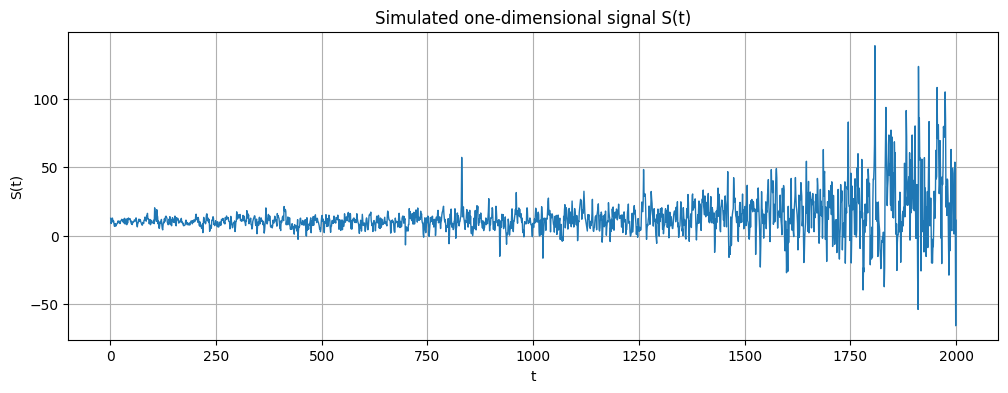

In [4]:
t = simulation["t"]

plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], linewidth=1)
plt.title("Simulated one-dimensional signal S(t)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

The simulated signal shows three qualitative stages. In the initial part, the variability is relatively low. Later, both the trend and the scale increase. In the final regime, the signal becomes much more volatile, which reflects the accelerated degradation stage.

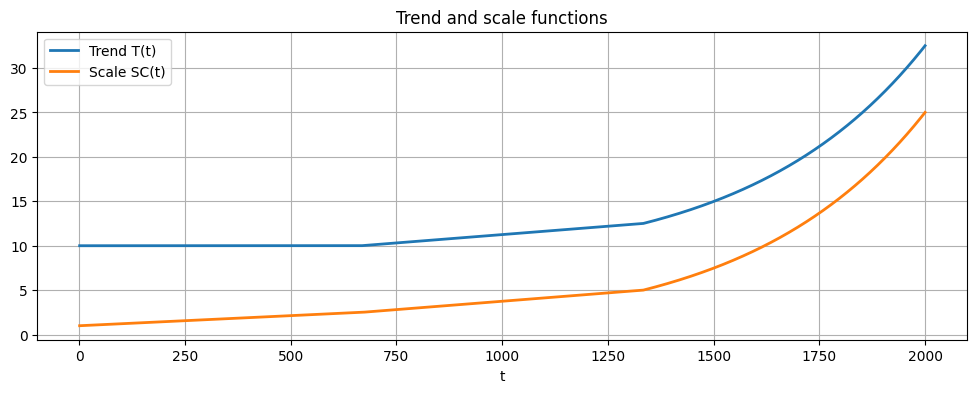

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["T"], label="Trend T(t)", linewidth=2)
plt.plot(t, simulation["SC"], label="Scale SC(t)", linewidth=2)
plt.title("Trend and scale functions")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

The next table checks selected boundary values of the deterministic trend and scale. It is mainly a sanity check that the piecewise construction uses the intended initial and final levels.


In [6]:
SC = simulation["SC"]
T = simulation["T"]

idx_tau1 = int(tau1) - 1
idx_tau2 = int(tau2) - 1

boundary_check = pd.DataFrame({
    "quantity": ["SC(1)", "SC(tau1 approx)", "SC(tau2 approx)", "SC(N)", "T(1)", "T(N)"],
    "value": [
        SC[0],
        SC[idx_tau1],
        SC[idx_tau2],
        SC[-1],
        T[0],
        T[-1],
    ]
})

boundary_check

,quantity,value
0,SC(1),1.000000
1,SC(tau1 approx),2.498498
2,SC(tau2 approx),4.998750
3,SC(N),25.000000
4,T(1),10.000000
5,T(N),32.500000


## Estimation Procedure for the 1D Model

The estimation procedure reverses the simulation steps:

1. estimate the deterministic trend $T(t)$ using a moving median,
2. subtract the trend to obtain $\hat R(t)$,
3. estimate the time-varying scale $SC(t)$ using a robust scale estimator,
4. normalize the random component, $\hat R2(t)=\hat R(t)/\widehat{SC}(t)$,
5. fit an AR model to $\hat R2(t)$,
6. compute residuals $\hat R3(t)$,
7. estimate $\alpha$ from the residuals using McCulloch's quantile method.

For the single trajectory below the candidate AR orders are compared using a robust residual ACF diagnostic. In the Monte Carlo section the order is fixed at AR(1), because that is the data-generating model.


In [7]:
est = estimate_1d_model(
    simulation["S"],
    trend_window=101,
    scale_window=151,
    p_max=5,
    h_max=30,
    include_zero_order=True,
    relative_tolerance=0.10,
)

summarize_1d_estimation(est)

One-dimensional estimation summary
---------------------------------
Estimated AR order p_opt: 1
Estimated phi: [0.50130107]
Estimated intercept: 0.0
Estimated alpha: 1.9127

AR order candidates:
  p=0: K=0.251303
  p=1: K=0.00372695
  p=2: K=0.00390953
  p=3: K=0.00393131
  p=4: K=0.00357815
  p=5: K=0.00373268


The trend plot compares the true deterministic trend with the moving-median estimate. The observed signal is shown in the background to make the difficulty of trend extraction under heavy-tailed noise visible.


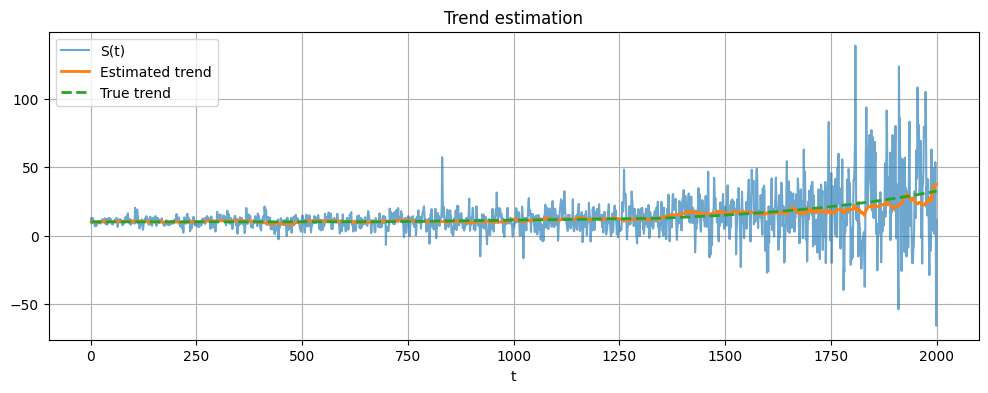

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], label="S(t)", alpha=0.65)
plt.plot(t, est["T_hat"], label="Estimated trend", linewidth=2)
plt.plot(t, simulation["T"], label="True trend", linewidth=2, linestyle="--")
plt.title("Trend estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

The scale plot checks whether the robust scale estimator recovers the increasing volatility pattern. The most important feature is the shape of the scale curve, especially the strong growth in the alarm regime.


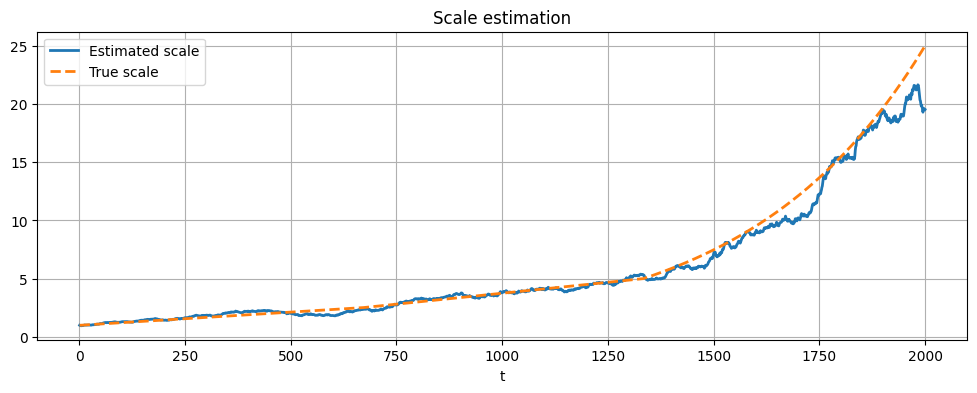

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["SC_hat"], label="Estimated scale", linewidth=2)
plt.plot(t, simulation["SC"], label="True scale", linewidth=2, linestyle="--")
plt.title("Scale estimation")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

After subtracting the trend and dividing by the estimated scale, the component $\hat R2(t)$ should be approximately stationary. Remaining temporal dependence is then handled by the AR(1) model.


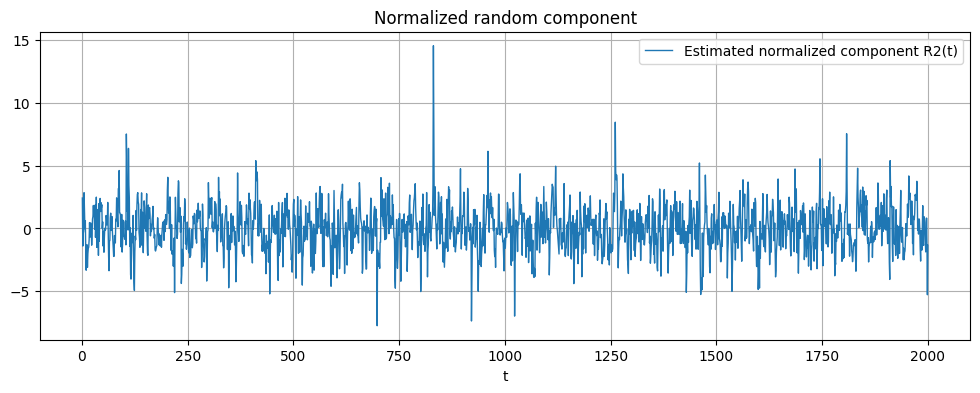

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(t, est["R2_hat"], label="Estimated normalized component R2(t)", linewidth=1)
plt.title("Normalized random component")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

The robust ACF before AR fitting should show temporal dependence inherited from the AR(1) process. After fitting AR(1), the residual ACF should be much closer to zero, indicating that the main serial dependence has been removed.


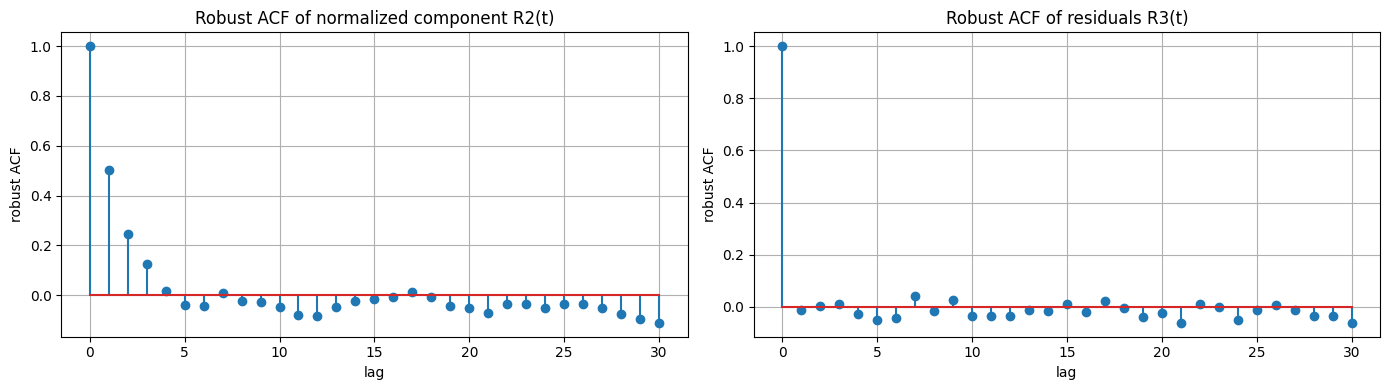

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].stem(range(len(est["acf_R2"])), est["acf_R2"])
axes[0].set_title("Robust ACF of normalized component R2(t)")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("robust ACF")
axes[0].grid(True)

axes[1].stem(range(len(est["acf_R3"])), est["acf_R3"])
axes[1].set_title("Robust ACF of residuals R3(t)")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("robust ACF")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **MOŻNA DODAĆ CI WYŻĘJ**

In [12]:
ar_table = pd.DataFrame([
    {
        "p": item["p"],
        "K": item["K"],
        "selected": item["p"] == est["p_opt"],
    }
    for item in est["ar_candidates"]
])

ar_table

,p,K,selected
0,0,0.251303,False
1,1,0.003727,True
2,2,0.003910,False
3,3,0.003931,False
4,4,0.003578,False
5,5,0.003733,False


### **TUTAJ DOPISAĆ CO ZYSKUJEMY NA TYM WYBORZE, MNIEJ SKOMPLIKOWANY MODEL -> MORE FLEXIBILITY, ALE W TYM PRZPYADKU WIADOMO, ZE SYMMULUJEMY DANE Z AR(1) WIEC CHYBA NAWET NIE MA SENSU SPRAWDZAC TEJ STATYSTYKI?**

The diagnostic statistic $K$ is computed from the robust ACF of residuals. The absolute minimum can sometimes be obtained by a higher-order AR model, but a small improvement may not justify the extra parameters. Therefore, the report uses the smallest order whose diagnostic statistic is within 10% of the best value.

Here this rule selects $p=1$, which is consistent with the simulated AR(1) mechanism.


In [13]:
single_run_summary = pd.DataFrame({
    "parameter": ["alpha", "phi", "AR order"],
    "true value": [1.9, 0.5, 1],
    "estimated value": [
        est["alpha_hat"],
        est["phi_hat"][0] if len(est["phi_hat"]) > 0 else np.nan,
        est["p_opt"],
    ],
})

single_run_summary

,parameter,true value,estimated value
0,alpha,1.9,1.912686
1,phi,0.5,0.501301
2,AR order,1.0,1.000000


## Comparison Across Stability Indices

To illustrate the role of the stability index, the same simulation-estimation pipeline is repeated for

$$
\alpha\in\{1.85,1.90,1.95,2.00\}.
$$

Lower values of $\alpha$ produce heavier tails and more impulsive paths. The Gaussian boundary case $\alpha=2$ is included as a reference.


In [14]:
alphas = [2.0, 1.95, 1.9, 1.85]

simulations_by_alpha = {}
estimations_by_alpha = {}

for alpha in alphas:
    sim_alpha = simulate_1d_model(
        **base_params,
        alpha=alpha,
        random_state=42,
    )

    est_alpha = estimate_1d_model(
        sim_alpha["S"],
        trend_window=101,
        scale_window=151,
        p_max=5,
        h_max=30,
        include_zero_order=True,
        relative_tolerance=0.10,
    )

    simulations_by_alpha[alpha] = sim_alpha
    estimations_by_alpha[alpha] = est_alpha

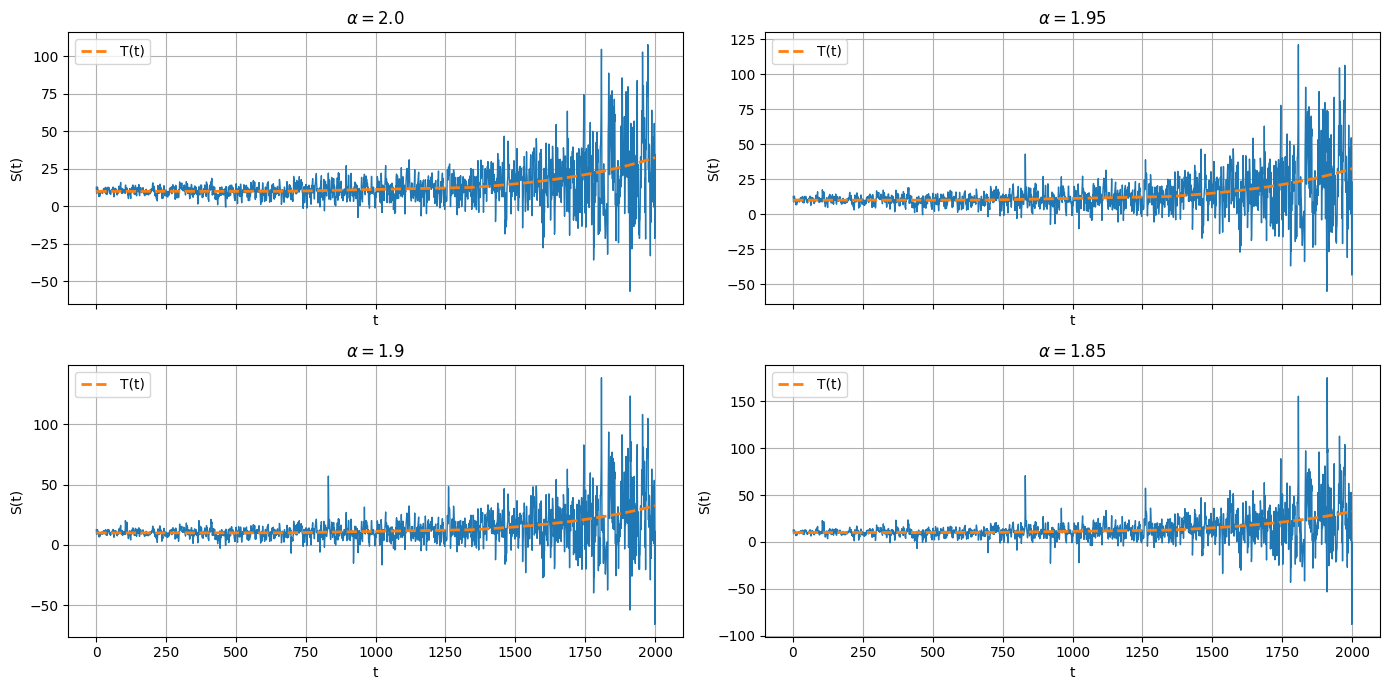

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.ravel()

for ax, alpha in zip(axes, alphas):
    sim_alpha = simulations_by_alpha[alpha]
    ax.plot(sim_alpha["t"], sim_alpha["S"], linewidth=1)
    ax.plot(sim_alpha["t"], sim_alpha["T"], linewidth=2, linestyle="--", label="T(t)")
    ax.set_title(rf"$\alpha = {alpha}$")
    ax.set_xlabel("t")
    ax.set_ylabel("S(t)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [149]:
alpha_comparison_rows = []

for alpha in alphas:
    est_alpha = estimations_by_alpha[alpha]

    phi_est = est_alpha["phi_hat"][0] if len(est_alpha["phi_hat"]) > 0 else np.nan

    alpha_comparison_rows.append({
        "true_alpha": alpha,
        "estimated_alpha": est_alpha["alpha_hat"],
        "true_phi": 0.5,
        "estimated_phi": phi_est,
        "p_opt": est_alpha["p_opt"],
    })

alpha_comparison = pd.DataFrame(alpha_comparison_rows)
alpha_comparison

,true_alpha,estimated_alpha,true_phi,estimated_phi,p_opt
0,2.00,2.000000,0.5,0.492804,1
1,1.95,1.970024,0.5,0.497912,1
2,1.90,1.912686,0.5,0.501301,1
3,1.85,1.845556,0.5,0.503290,1


## Monte Carlo Study for the 1D Model

The Monte Carlo study checks whether the estimation pipeline recovers known parameters when the data-generating model is known. For each stability index

$$
\alpha\in\{1.85,1.90,1.95,2.00\},
$$

we simulate $M=100$ independent trajectories of length $N=2000$. The true AR parameter is $\phi_{true}=0.5$. For this final experiment the AR order is fixed at 1, and the trend window is set to 501 after diagnostic checks of the trend/scale reconstruction.


Reusable Monte Carlo runners and report-style plotting functions are imported from `monte_carlo_utils.py` and `plotting_utils.py`.

The next cell recomputes the full 1D Monte Carlo experiment. It is intentionally kept as code rather than hidden state, but it can take longer than the single-trajectory examples.


In [124]:
mc_1d_final = {}

alphas_order = [1.85, 1.90, 1.95, 2.00]
n_replications = 100

for idx, alpha in enumerate(alphas_order):
    print(f"Running FINAL Monte Carlo for alpha={alpha}...")
    mc_1d_final[alpha] = run_mc_1d_for_alpha(
        alpha=alpha,
        base_params=base_params,
        n_replications=n_replications,
        base_seed=10_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
    )

print("Done.")

Running FINAL Monte Carlo for alpha=1.85...
Running FINAL Monte Carlo for alpha=1.9...
Running FINAL Monte Carlo for alpha=1.95...
Running FINAL Monte Carlo for alpha=2.0...
Done.


The summary table reports the centre and spread of the estimated $\alpha$ and $\phi$. Since the data were generated with known values, the comparison with the true parameters directly measures the performance of the estimator pipeline.


In [129]:
mc_summary_rows = []

for alpha in alphas_order:
    result = mc_1d_final[alpha]

    mc_summary_rows.append({
        "true_alpha": alpha,
        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "mean_phi_hat": np.mean(result["phi_hats"]),
        "std_phi_hat": np.std(result["phi_hats"], ddof=1),
        "median_phi_hat": np.median(result["phi_hats"]),
        "true_phi": 0.5,
        "n_replications": n_replications,
    })

mc_summary_1d = pd.DataFrame(mc_summary_rows)
mc_summary_1d

,true_alpha,mean_alpha_hat,std_alpha_hat,median_alpha_hat,mean_phi_hat,std_phi_hat,median_phi_hat,true_phi,n_replications
0,1.85,1.867957,0.072825,1.866071,0.506525,0.020441,0.507124,0.5,100
1,1.90,1.908314,0.064777,1.913825,0.500638,0.021544,0.502745,0.5,100
2,1.95,1.939421,0.057825,1.954353,0.496793,0.020993,0.495754,0.5,100
3,2.00,1.971059,0.046542,2.000000,0.491720,0.022605,0.494268,0.5,100


The Monte Carlo plots show the variability of the estimated trend and scale curves, followed by boxplots of $\hat\phi$ and $\hat\alpha$. For $\alpha=2$, the alpha estimates are bounded above by 2, so the corresponding boxplot can look visibly truncated at the upper boundary.


# BRAKUJE NA PEWNO ESTIMATED RESIDUALS AFTER

## **NO BRAKUJE ACF TUTAJ - JEST NIZEJ, A POWINNO BYC PO KOLEI, CZYLI: 1. TREND I SKALA, 2. ACF, 3. FITOWANIE AR (BOXPLOT THETA) 4. ACF PO 5.ALPHA**

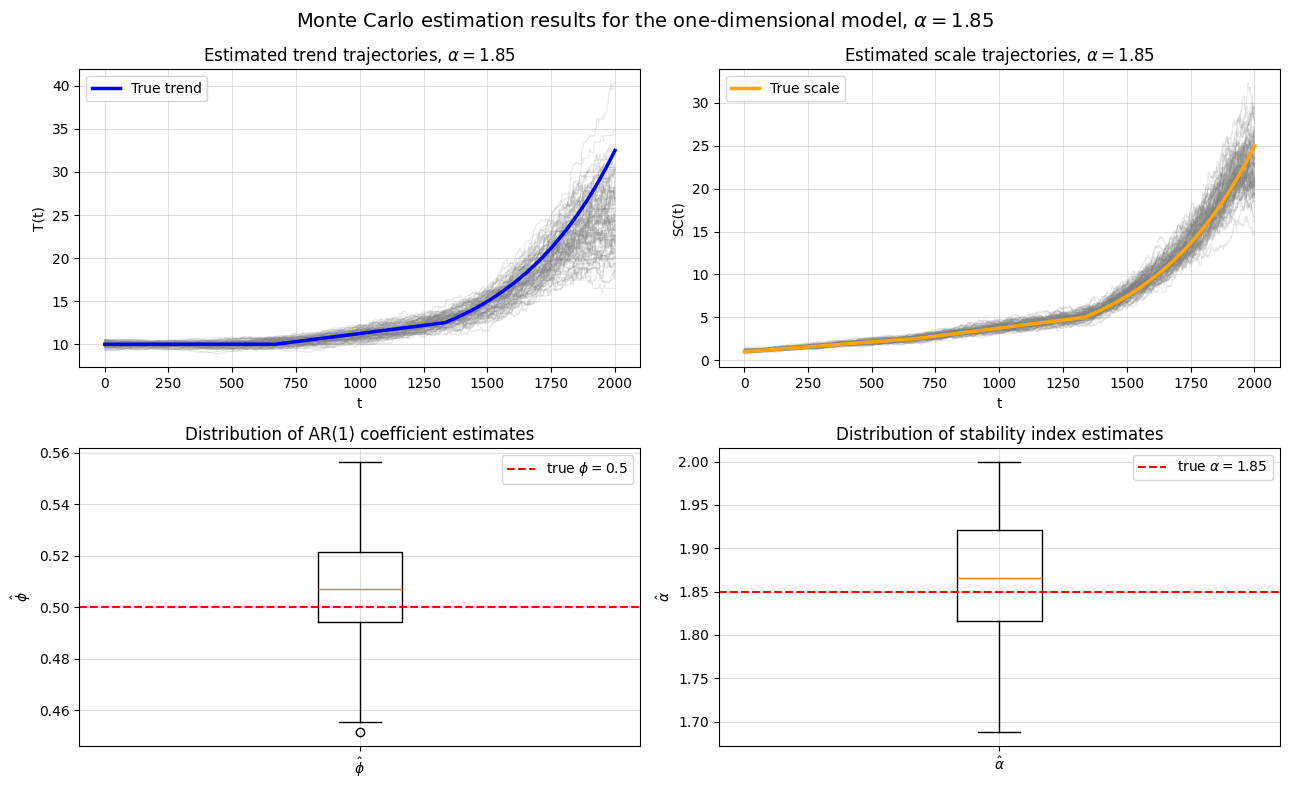

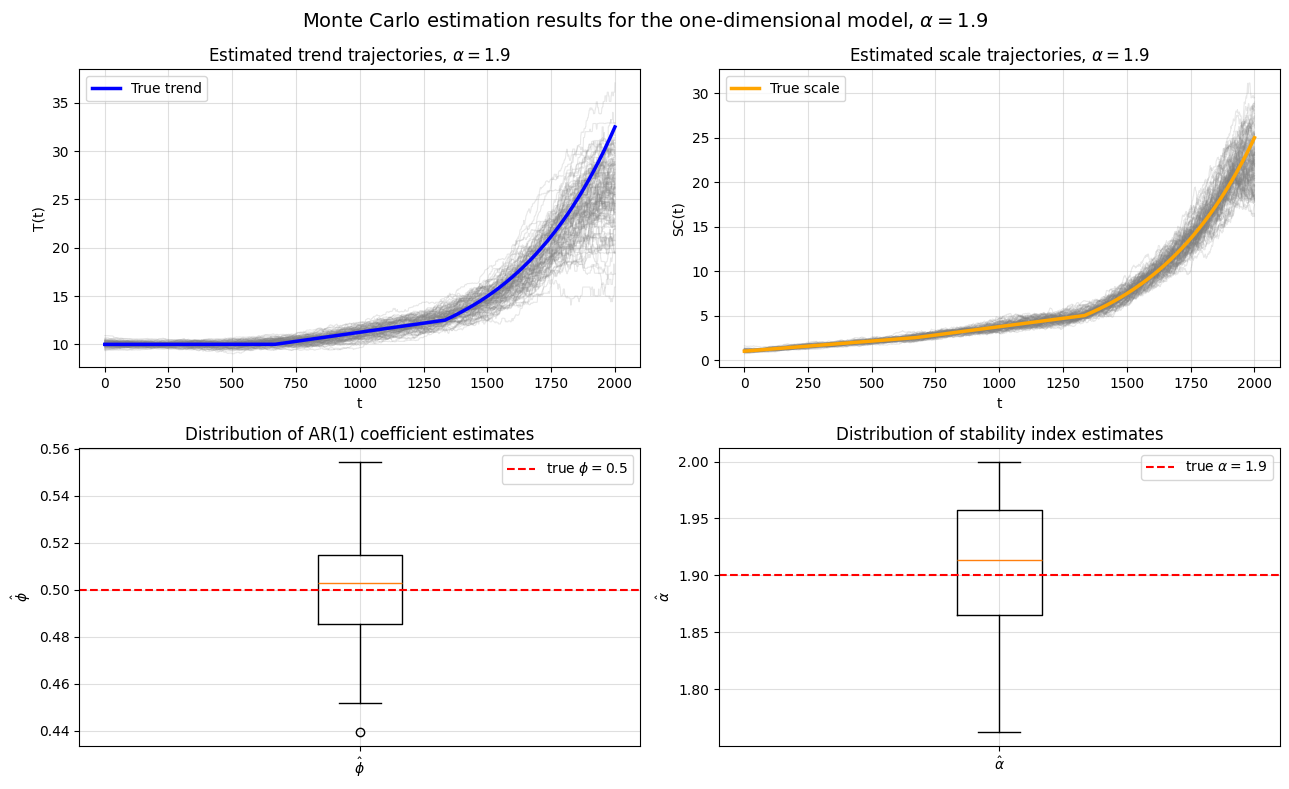

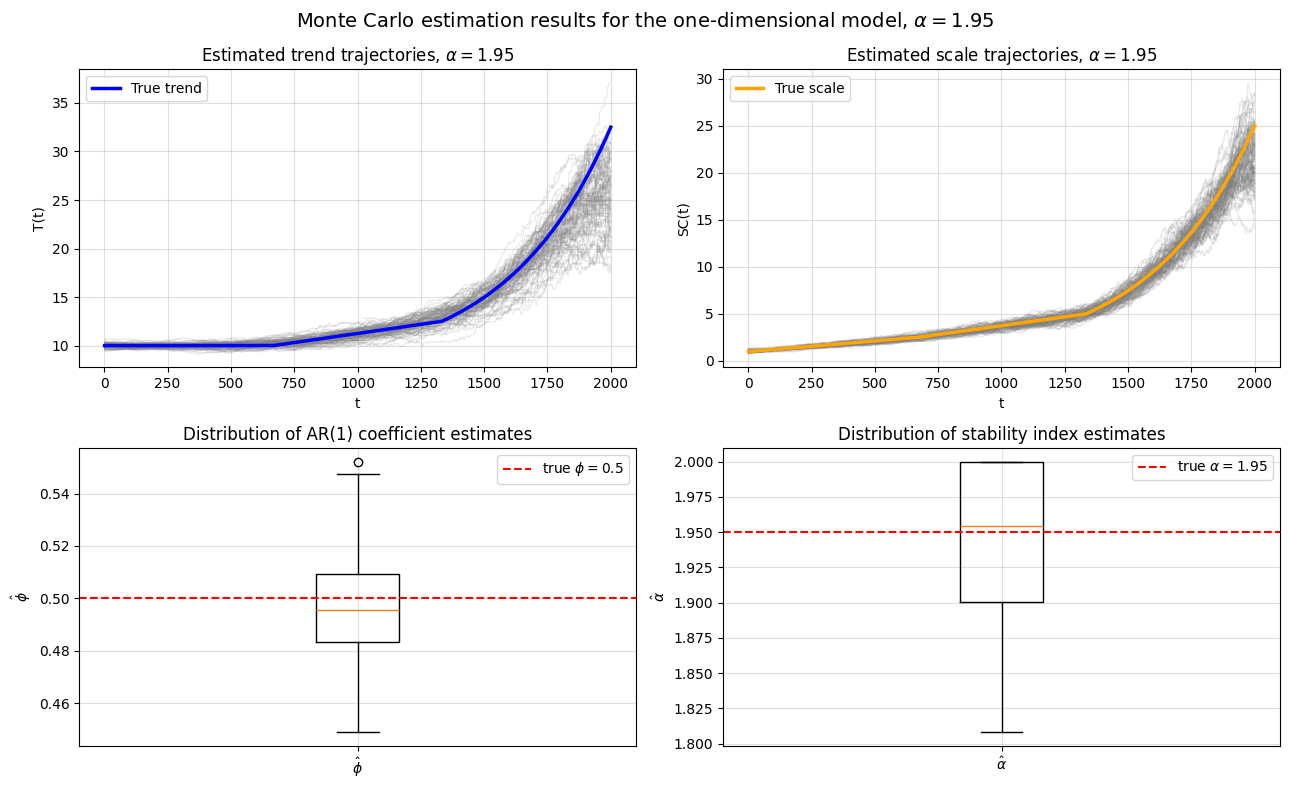

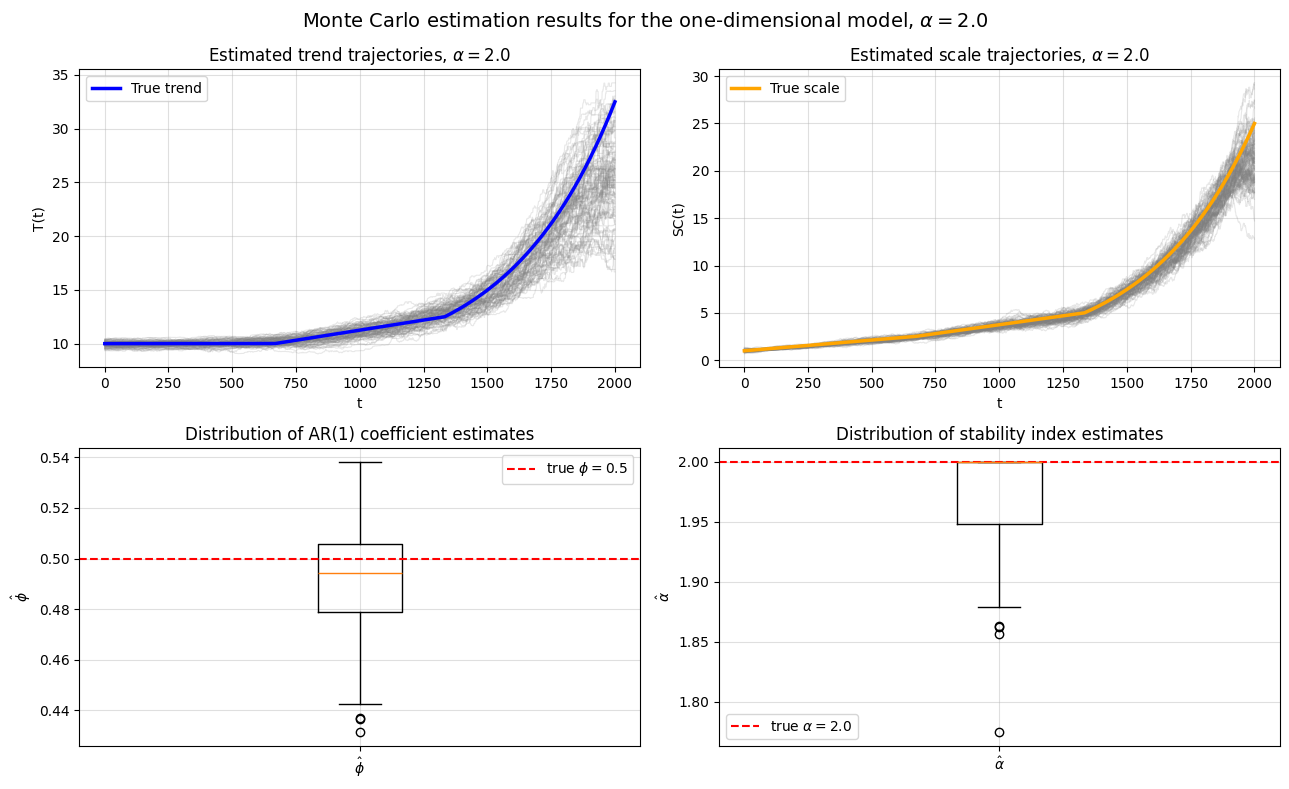

In [126]:
for alpha in alphas_order:
    plot_mc_1d_estimation_results(mc_1d_final[alpha], true_phi=0.5)

The representative ACF plots compare the normalized component before AR(1) fitting with the residuals after AR(1). A successful fit should leave the residual ACF mostly within the approximate confidence bands.


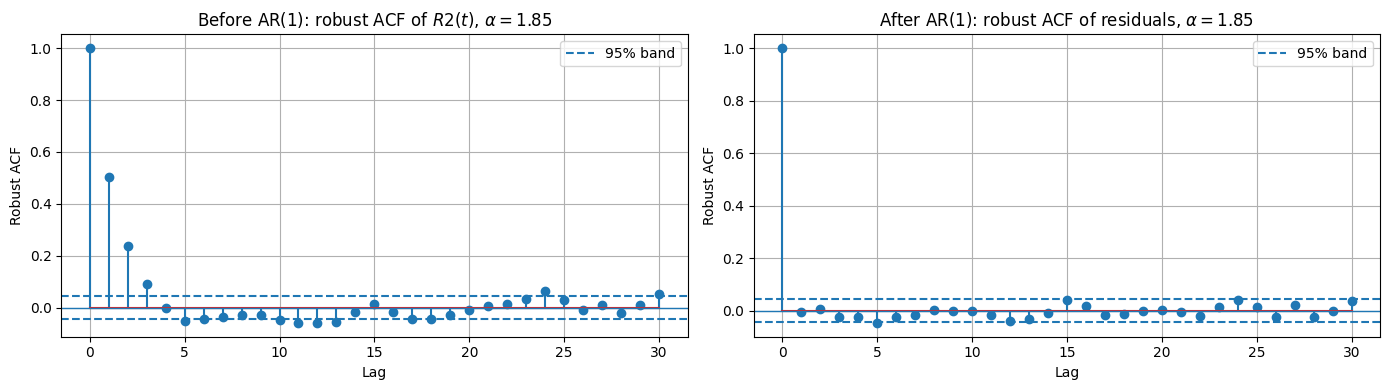

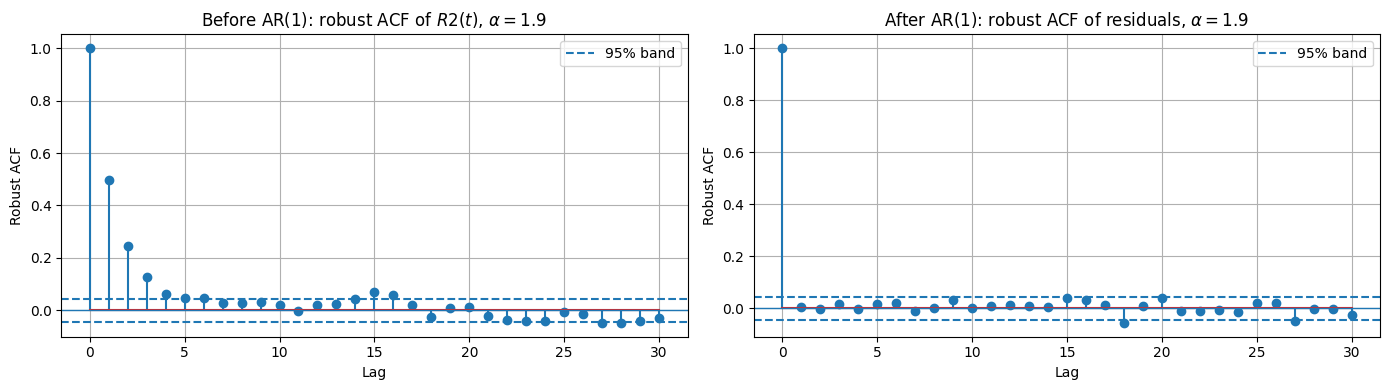

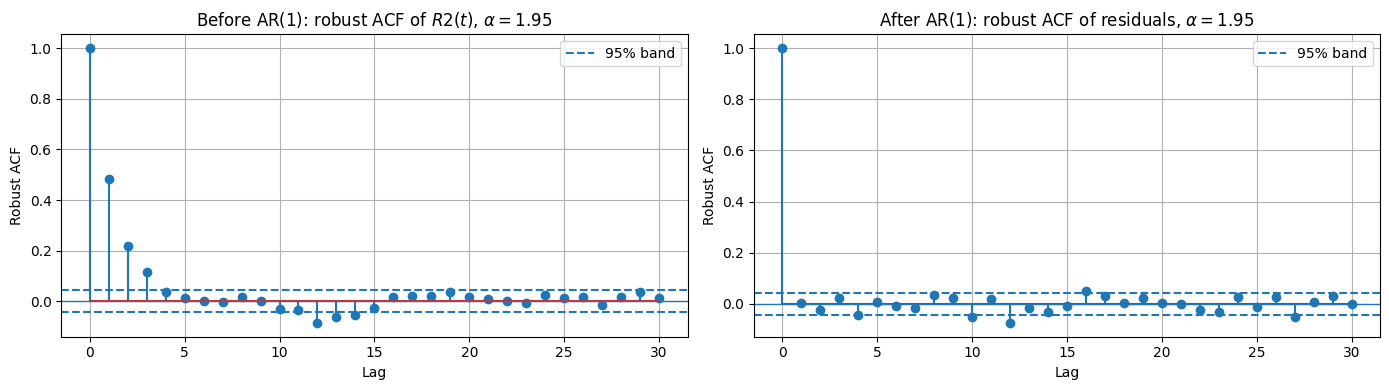

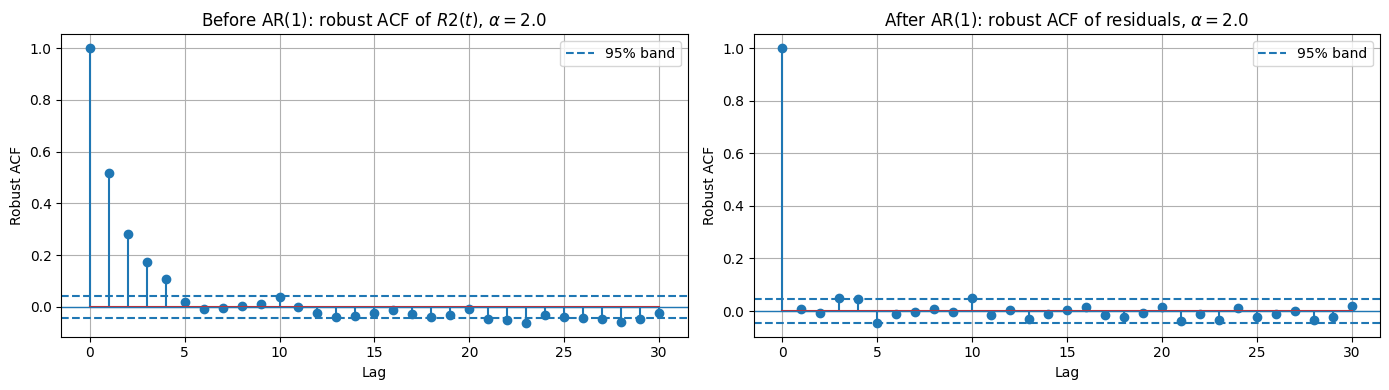

In [130]:
for alpha in alphas_order:
    plot_representative_acf_1d(mc_1d_final[alpha], ci_level=0.95)

The median curves and 5%-95% bands summarize the reconstruction uncertainty for the trend and scale functions across Monte Carlo replications.


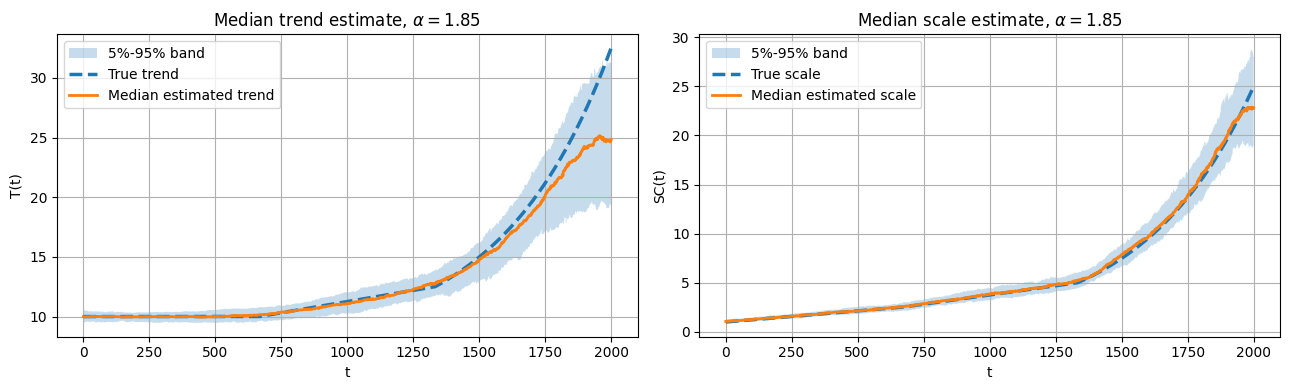

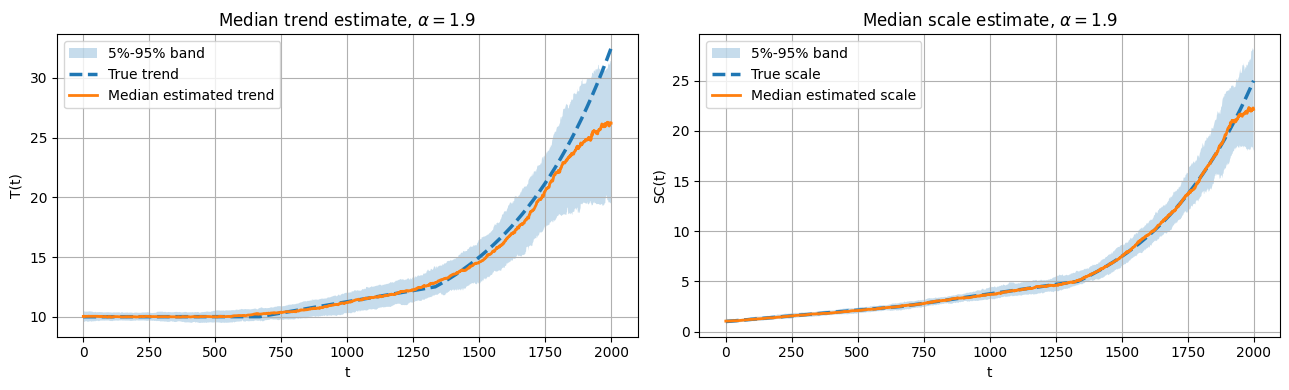

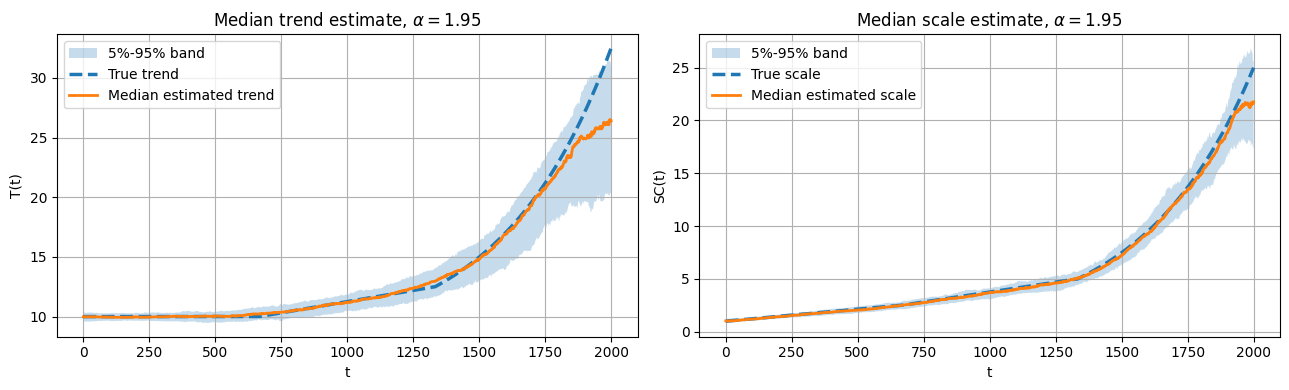

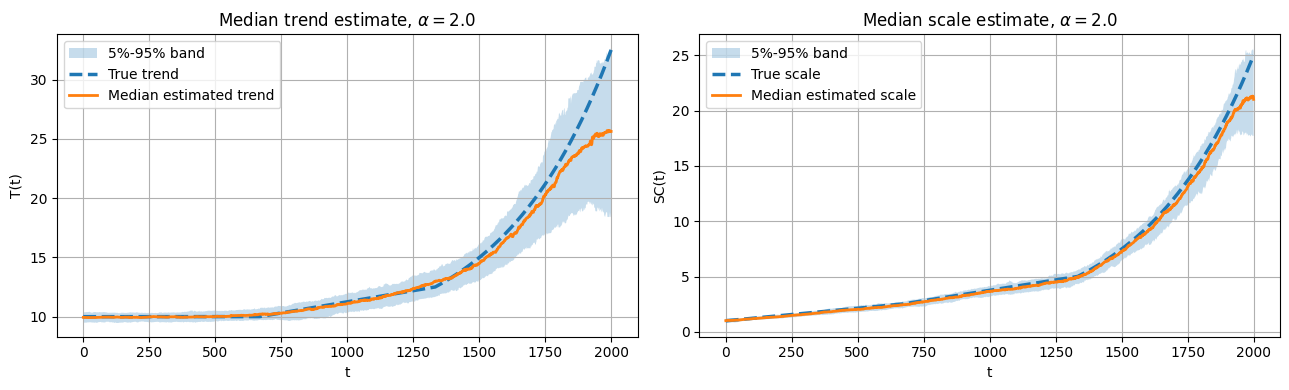

In [127]:
for alpha in alphas_order:
    plot_mc_1d_median_band(mc_1d_final[alpha])

## **TU NIZEJ TAK SAMO - MAMY VAR(P) MODEL, TO GO POKAZMY, A NIE TYLKO VAR(1), MOZNA TEZ DODAC COS O ROZKLADACH SUBGAUSSOWSKICH, JAK ONE POWSTAJA**

## Two-Dimensional Model

The multidimensional model extends the same idea to a vector health index,

$$
\mathbf S(t)=\mathbf R(t)+\mathbf T(t).
$$

Both components share the same regime-change points, which means that the physical machine moves through the same degradation regimes in both measured directions. However, each component has its own trend and scale function, because different sensors or vibration directions can react with different amplitudes.

After trend removal and scale normalization, the temporal dynamics are described by a VAR model. In the simulated 2D study we use

$$
\mathbf R2(t)=\Theta\mathbf R2(t-1)+\mathbf R3(t),
$$

where $\Theta$ captures lagged within-component and cross-component dependence. The residual vector $\mathbf R3(t)$ follows a sub-Gaussian $S\alpha S$ distribution. Its matrix $\Sigma$ controls contemporaneous dependence between components, which is why lag-0 CCF is not expected to disappear after VAR fitting.

## **NO TU NIE DO KONCA PRAWDA ZE TE SAME PARAMETRY, BO SA DWA TRENDY I DWIE SKALE - ROZNE NIZ W 1D ALE OK, BO BY BYLO ZA DUZO PARAMETROW MOZE**

## Simulation Parameters for the 2D Model

The two-dimensional simulation uses the same length and change points as the 1D model. The true VAR(1) and dependence matrices are

$$
\Theta_{true}=\begin{bmatrix}0.5&0.2\\-0.1&0.6\end{bmatrix},\quad
\Sigma_{true}=\begin{bmatrix}0.64&0.32\\0.32&0.64\end{bmatrix}.
$$

The two components have different trend and scale levels, which lets us test whether the pipeline works componentwise while still preserving cross-dependence.


In [151]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

Theta_true = np.array([
    [0.5, 0.2],
    [-0.1, 0.6],
])

Sigma_true = np.array([
    [0.64, 0.32],
    [0.32, 0.64],
])

base_params_2d = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    Theta=Theta_true,
    Sigma=Sigma_true,
    sigma_1=np.array([1.0, 0.8]),
    sigma_2=np.array([2.5, 1.5]),
    sigma_3=np.array([5.0, 2.0]),
    sigma_4=np.array([25.0, 10.0]),
    c1=np.array([10.0, -5.0]),
)

## Simulation of the 2D Model

We again start from one trajectory with $\alpha=1.9$. The two panels below show the two observed components of the simulated health index. The components are not independent: they are coupled through both the VAR(1) matrix and the sub-Gaussian innovation matrix $\Sigma$.


In [ ]:
sim2d = simulate_2d_model(
    **base_params_2d,
    alpha=1.9,
    random_state=42,
)


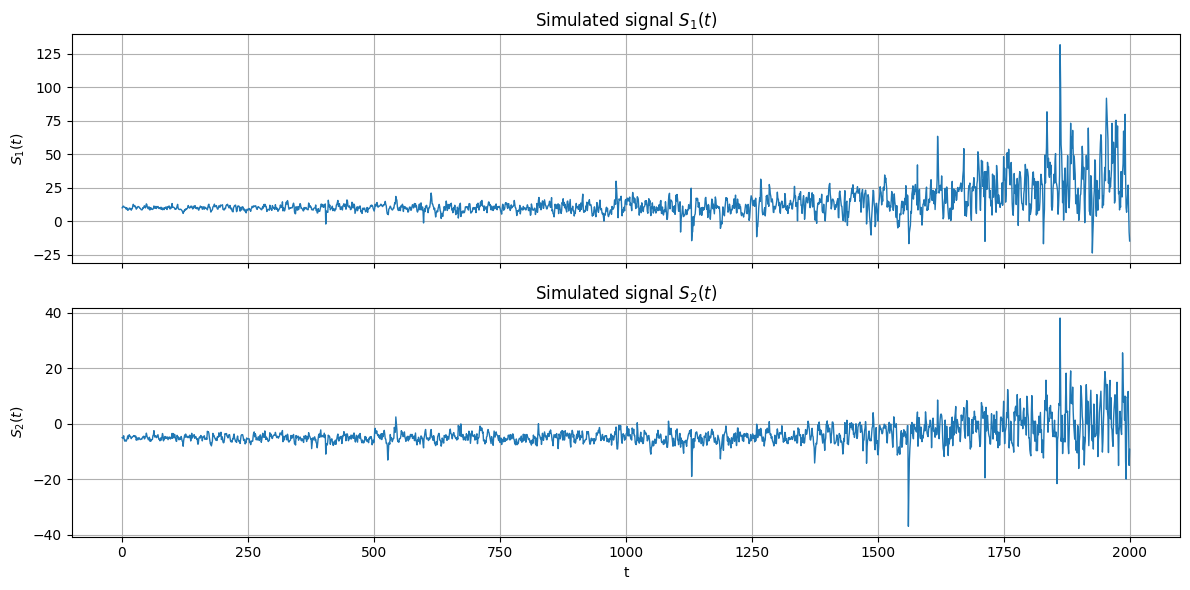

In [153]:
t = sim2d["t"]
S = sim2d["S"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, S[:, 0], linewidth=1)
axes[0].set_title(r"Simulated signal $S_1(t)$")
axes[0].set_ylabel(r"$S_1(t)$")
axes[0].grid(True)

axes[1].plot(t, S[:, 1], linewidth=1)
axes[1].set_title(r"Simulated signal $S_2(t)$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$S_2(t)$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The next figure shows the deterministic trend and scale functions used in the simulation. The change points are common, but the component-specific levels and growth rates are different.


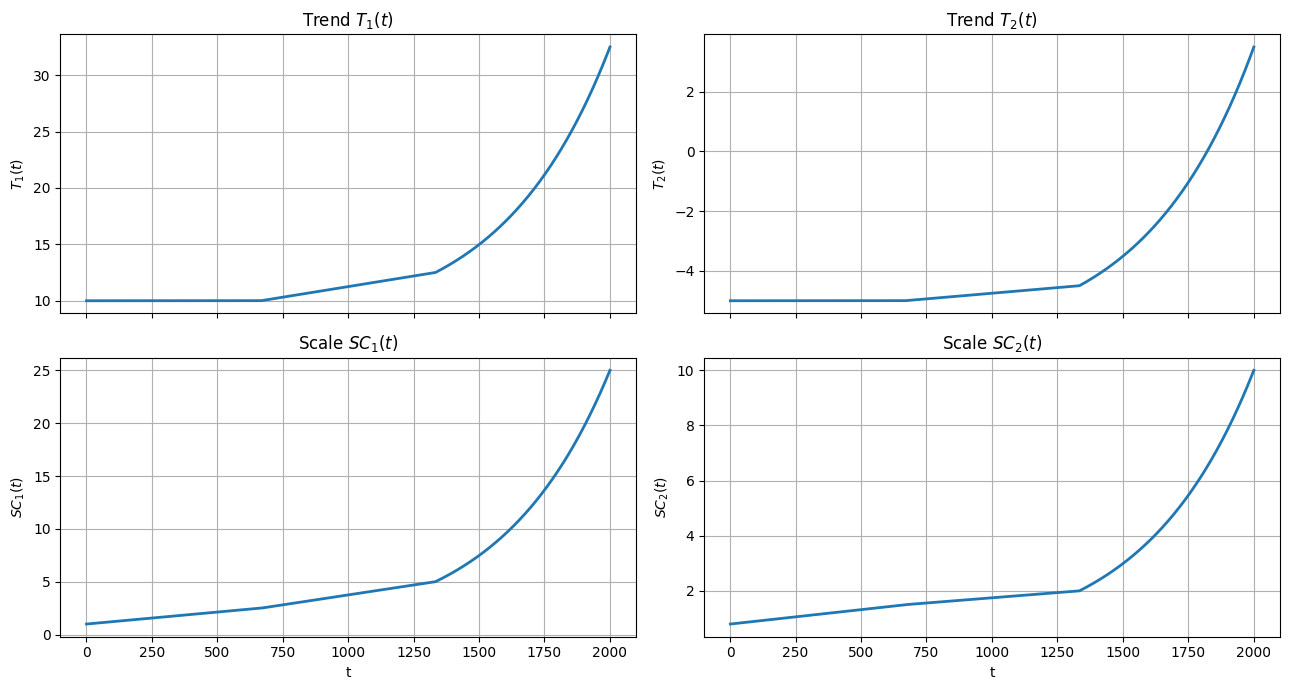

In [154]:
T = sim2d["T"]
SC = sim2d["SC"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

axes[0, 0].plot(t, T[:, 0], linewidth=2)
axes[0, 0].set_title(r"Trend $T_1(t)$")
axes[0, 0].set_ylabel(r"$T_1(t)$")
axes[0, 0].grid(True)

axes[0, 1].plot(t, T[:, 1], linewidth=2)
axes[0, 1].set_title(r"Trend $T_2(t)$")
axes[0, 1].set_ylabel(r"$T_2(t)$")
axes[0, 1].grid(True)

axes[1, 0].plot(t, SC[:, 0], linewidth=2)
axes[1, 0].set_title(r"Scale $SC_1(t)$")
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel(r"$SC_1(t)$")
axes[1, 0].grid(True)

axes[1, 1].plot(t, SC[:, 1], linewidth=2)
axes[1, 1].set_title(r"Scale $SC_2(t)$")
axes[1, 1].set_xlabel("t")
axes[1, 1].set_ylabel(r"$SC_2(t)$")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("Theta_true =")
print(Theta_true)

print("\nSigma_true =")
print(Sigma_true)


## **TUTAJ MOZNA BY POKAZAC ALGORYTM NA 2D, A NIE TYLKO POWIEDZIEC ZE JEST TAKI SAM - TROCHE RZECZY SIE ZMIENIA - TEARZ MAMY VAR, CCF, MACIERZ SIGMA, ITP.**

## Estimation Procedure for the 2D Model

The 2D estimation pipeline follows the same sequence as the 1D pipeline, but all quantities are now vectors. After componentwise trend and scale estimation, the normalized component is fitted with VAR(1). The procedure estimates

- the autoregressive matrix $\Theta$,
- the stability index $\alpha$,
- and, in the extended Sigma experiment, the dependence matrix $\Sigma$ from the empirical characteristic function of the residuals.


In [223]:
est2d = estimate_2d_model_fixed_var1(
    sim2d["S"],
    trend_window=501,
    scale_window=151,
    h_max=30,
    compute_diagnostics=True,
    scale_multiplier=1.6629888237094692,
)

summarize_2d_estimation(est2d)


Two-dimensional estimation summary
----------------------------------
Estimated Theta:
[[ 0.49545282  0.19921618]
 [-0.12965311  0.62248887]]

Estimated alpha: 1.8591

Componentwise alpha:
  alpha_1: 1.8422
  alpha_2: 1.8760


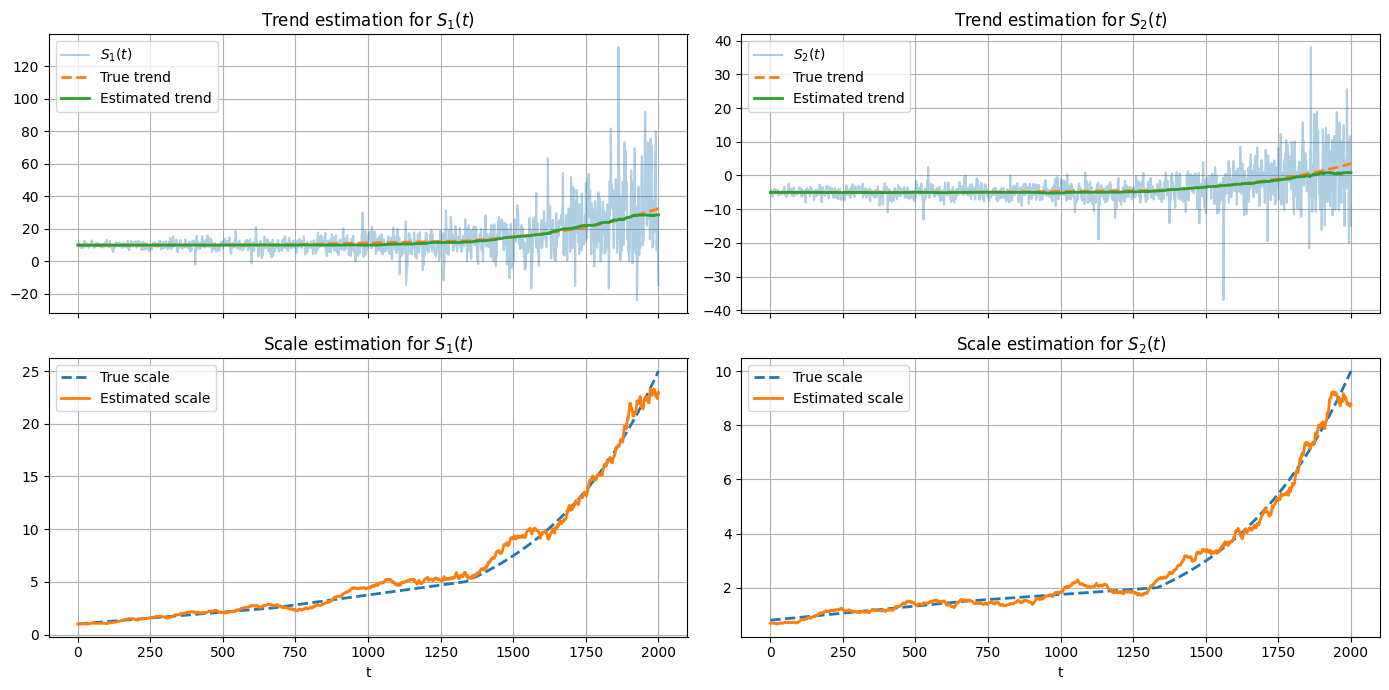

In [224]:
t = sim2d["t"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

axes[0, 0].plot(t, sim2d["S"][:, 0], alpha=0.35, label=r"$S_1(t)$")
axes[0, 0].plot(t, sim2d["T"][:, 0], linestyle="--", linewidth=2, label="True trend")
axes[0, 0].plot(t, est2d["T_hat"][:, 0], linewidth=2, label="Estimated trend")
axes[0, 0].set_title(r"Trend estimation for $S_1(t)$")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(t, sim2d["S"][:, 1], alpha=0.35, label=r"$S_2(t)$")
axes[0, 1].plot(t, sim2d["T"][:, 1], linestyle="--", linewidth=2, label="True trend")
axes[0, 1].plot(t, est2d["T_hat"][:, 1], linewidth=2, label="Estimated trend")
axes[0, 1].set_title(r"Trend estimation for $S_2(t)$")
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(t, sim2d["SC"][:, 0], linestyle="--", linewidth=2, label="True scale")
axes[1, 0].plot(t, est2d["SC_hat"][:, 0], linewidth=2, label="Estimated scale")
axes[1, 0].set_title(r"Scale estimation for $S_1(t)$")
axes[1, 0].set_xlabel("t")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(t, sim2d["SC"][:, 1], linestyle="--", linewidth=2, label="True scale")
axes[1, 1].plot(t, est2d["SC_hat"][:, 1], linewidth=2, label="Estimated scale")
axes[1, 1].set_title(r"Scale estimation for $S_2(t)$")
axes[1, 1].set_xlabel("t")
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The normalized components and VAR(1) residuals show the two stages of the random-part estimation: first stationarization by trend/scale removal, then removal of lagged dependence by VAR(1).


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=False)

R2_hat = est2d["R2_hat"]
R3_hat = est2d["R3_hat"]
t_R2 = np.arange(1, len(R2_hat) + 1)
t_R3 = np.arange(1, len(R3_hat) + 1)

axes[0, 0].plot(t_R2, R2_hat[:, 0], linewidth=1)
axes[0, 0].axhline(0, color="red", linewidth=1)
axes[0, 0].set_title(r"Normalized component $\hat{R2}_1(t)$")
axes[0, 0].set_ylabel(r"$\hat{R2}_1(t)$")

axes[0, 1].plot(t_R2, R2_hat[:, 1], linewidth=1)
axes[0, 1].axhline(0, color="red", linewidth=1)
axes[0, 1].set_title(r"Normalized component $\hat{R2}_2(t)$")
axes[0, 1].set_ylabel(r"$\hat{R2}_2(t)$")

axes[1, 0].plot(t_R3, R3_hat[:, 0], linewidth=1)
axes[1, 0].axhline(0, color="red", linewidth=1)
axes[1, 0].set_title(r"Residuals after VAR(1): $\hat{R3}_1(t)$")
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel(r"$\hat{R3}_1(t)$")

axes[1, 1].plot(t_R3, R3_hat[:, 1], linewidth=1)
axes[1, 1].axhline(0, color="red", linewidth=1)
axes[1, 1].set_title(r"Residuals after VAR(1): $\hat{R3}_2(t)$")
axes[1, 1].set_xlabel("t")
axes[1, 1].set_ylabel(r"$\hat{R3}_2(t)$")

for ax in axes.ravel():
    ax.grid(True)

plt.tight_layout()
plt.show()


The ACF/CCF diagnostics compare the normalized component before VAR(1) fitting with residuals after VAR(1). Lags greater than zero should become small after fitting. The lag-0 CCF is interpreted differently: it does not have to disappear, because contemporaneous dependence between the two residual components is part of the innovation structure and is represented by $\Sigma$.


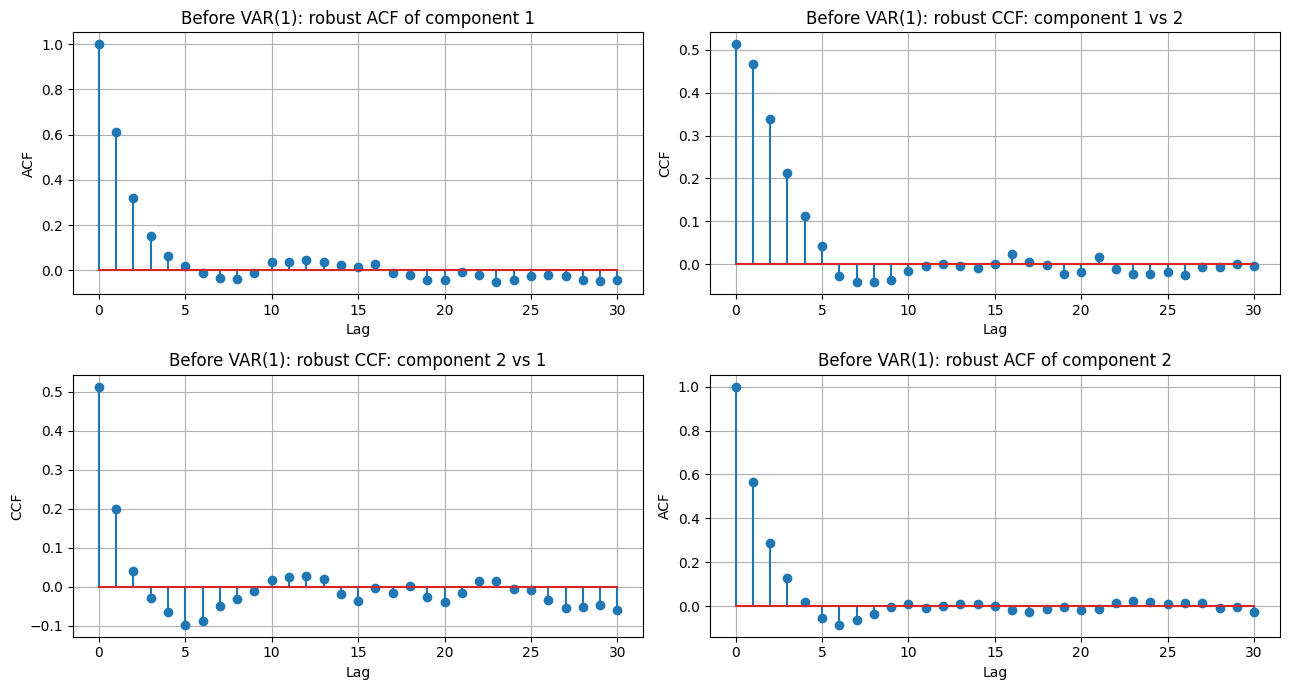

In [226]:
plot_2d_acf_ccf_diagnostics(
    est2d["diagnostics_R2"],
    title_prefix="Before VAR(1):"
)

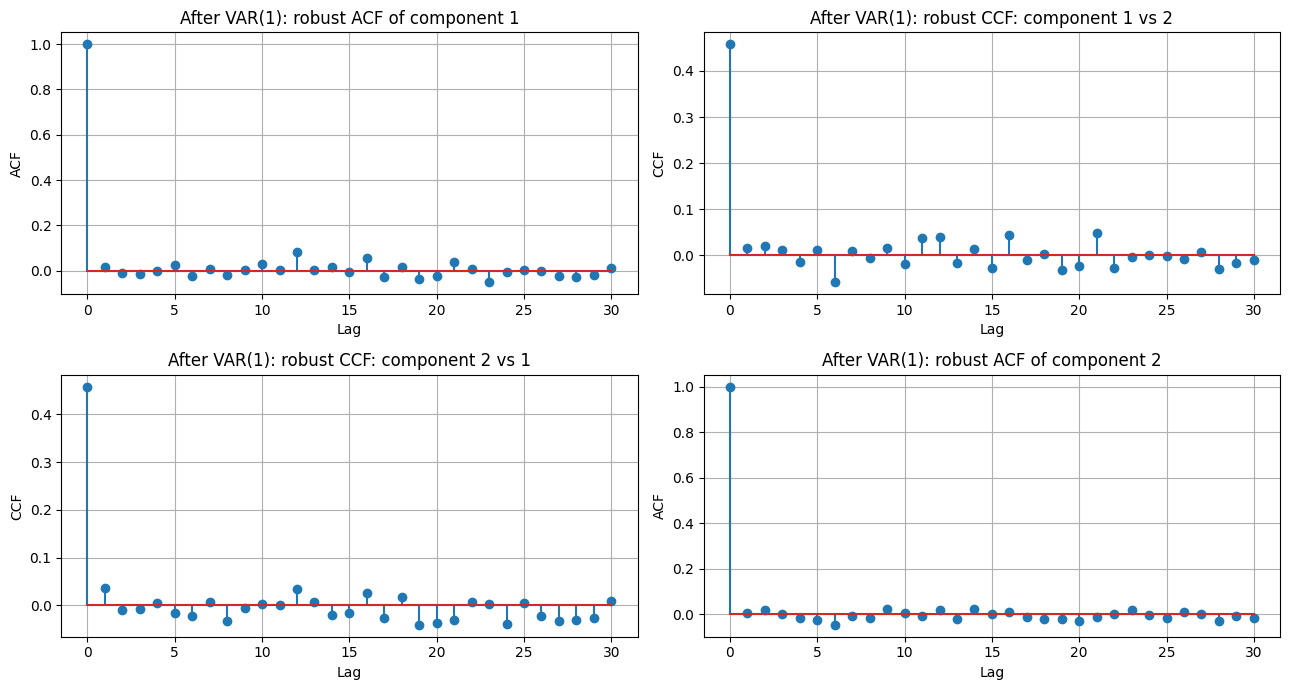

In [227]:
plot_2d_acf_ccf_diagnostics(
    est2d["diagnostics_R3"],
    title_prefix="After VAR(1):"
)

## Monte Carlo Study for the 2D Model

The two-dimensional Monte Carlo study checks whether the full simulation-estimation pipeline recovers known vector-model parameters. For each $\alpha\in\{1.85,1.90,1.95,2.00\}$, we simulate $M=100$ trajectories of length $N=2000$ and estimate the trend vectors, scale vectors, VAR(1) matrix $\Theta$ and stability index $\alpha$.

The true validation parameters are

$$
\Theta_{true}=\begin{bmatrix}0.5&0.2\\-0.1&0.6\end{bmatrix},\quad
\Sigma_{true}=\begin{bmatrix}0.64&0.32\\0.32&0.64\end{bmatrix}.
$$

This part is important because it separates implementation error from data uncertainty: in simulation the correct parameter values are known, so bias and variability of the estimators can be assessed directly.

## **TO NA PEWNO CHCEMY MOWIC? ON NIE PPOATRZY W KOD ZRODLOWY, LEPIEJ NIE POAKZYWAC ZE MAMY JAKIES POPRAWKI WPISANE Z PALCA**

### Two-Dimensional Scale Calibration

The robust scale estimator required a calibration of the absolute scale level in the two-dimensional model. A common multiplier $c_{2D}=1.663$ is used in the simulations. This is a calibration of the scale level, not a change in the mathematical model. It is reported explicitly because later Sigma estimates are sensitive to scale reconstruction errors.


In [19]:
scale_multiplier_2d = 1.6629888237094692
scale_multiplier_2d

1.6629888237094692

The next cell recomputes the 2D Monte Carlo study without estimating $\Sigma$ in each replication. It collects $\Theta$ and $\alpha$ estimates and stores one representative trajectory for ACF/CCF diagnostics.


In [182]:
alphas_order_2d = [1.85, 1.90, 1.95, 2.00]
n_replications_2d = 100

mc_2d_final_scaled = {}

for idx, alpha in enumerate(alphas_order_2d):
    print(f"Running scaled 2D Monte Carlo for alpha={alpha}...")
    mc_2d_final_scaled[alpha] = run_mc_2d_for_alpha(
        alpha=alpha,
        base_params_2d=base_params_2d,
        n_replications=n_replications_2d,
        base_seed=20_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
        scale_multiplier=scale_multiplier_2d,
    )

print("Done.")

Running scaled 2D Monte Carlo for alpha=1.85...
Running scaled 2D Monte Carlo for alpha=1.9...
Running scaled 2D Monte Carlo for alpha=1.95...
Running scaled 2D Monte Carlo for alpha=2.0...
Done.


In [186]:
mc_2d_summary_scaled_rows = []

for alpha in alphas_order_2d:
    result = mc_2d_final_scaled[alpha]
    Theta_hats = result["Theta_hats"]

    mc_2d_summary_scaled_rows.append({
        "true_alpha": alpha,

        "mean_alpha_hat": np.mean(result["alpha_hats"]),
        "median_alpha_hat": np.median(result["alpha_hats"]),
        "std_alpha_hat": np.std(result["alpha_hats"], ddof=1),

        "mean_alpha_1_hat": np.mean(result["alpha_1_hats"]),
        "mean_alpha_2_hat": np.mean(result["alpha_2_hats"]),

        "mean_theta_11": np.mean(Theta_hats[:, 0, 0]),
        "median_theta_11": np.median(Theta_hats[:, 0, 0]),
        "true_theta_11": Theta_true[0, 0],

        "mean_theta_12": np.mean(Theta_hats[:, 0, 1]),
        "median_theta_12": np.median(Theta_hats[:, 0, 1]),
        "true_theta_12": Theta_true[0, 1],

        "mean_theta_21": np.mean(Theta_hats[:, 1, 0]),
        "median_theta_21": np.median(Theta_hats[:, 1, 0]),
        "true_theta_21": Theta_true[1, 0],

        "mean_theta_22": np.mean(Theta_hats[:, 1, 1]),
        "median_theta_22": np.median(Theta_hats[:, 1, 1]),
        "true_theta_22": Theta_true[1, 1],

        "n_replications": n_replications_2d,
    })

mc_2d_summary_scaled = pd.DataFrame(mc_2d_summary_scaled_rows)
mc_2d_summary_scaled

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,mean_alpha_1_hat,mean_alpha_2_hat,mean_theta_11,median_theta_11,true_theta_11,mean_theta_12,median_theta_12,true_theta_12,mean_theta_21,median_theta_21,true_theta_21,mean_theta_22,median_theta_22,true_theta_22,n_replications
0,1.85,1.853972,1.852878,0.046767,1.852139,1.855805,0.488665,0.486248,0.5,0.188118,0.189874,0.2,-0.108152,-0.108307,-0.1,0.596985,0.597428,0.6,100
1,1.90,1.886680,1.890752,0.047744,1.887711,1.885649,0.497038,0.495775,0.5,0.188254,0.189149,0.2,-0.106244,-0.111650,-0.1,0.594643,0.594761,0.6,100
2,1.95,1.941391,1.939242,0.042502,1.941119,1.941662,0.490795,0.492372,0.5,0.195107,0.195034,0.2,-0.116733,-0.116132,-0.1,0.603795,0.608446,0.6,100
3,2.00,1.967227,1.974637,0.032468,1.965264,1.969190,0.490862,0.492024,0.5,0.192216,0.192791,0.2,-0.109185,-0.110934,-0.1,0.596896,0.596507,0.6,100


The Monte Carlo summary confirms that the VAR(1) matrix is estimated with reasonable accuracy. The diagonal entries $\Theta_{11}$ and $\Theta_{22}$ are recovered particularly well. The off-diagonal entries show slightly larger deviations, which is expected because they describe cross-dependence between components and are more sensitive to errors in trend and scale reconstruction.

The stability index $\alpha$ is also estimated reasonably well. The estimates are close to the true values for all considered cases, with a small downward bias visible for larger values of $\alpha$.

The first Monte Carlo figure set shows reconstructed trend and scale trajectories and boxplots of the four entries of $\Theta$. The off-diagonal entries are usually more variable because they describe cross-component lagged dependence.


## **NIZEJ TAK JAK WCZESNIEJ - CHRONOLOGIA**

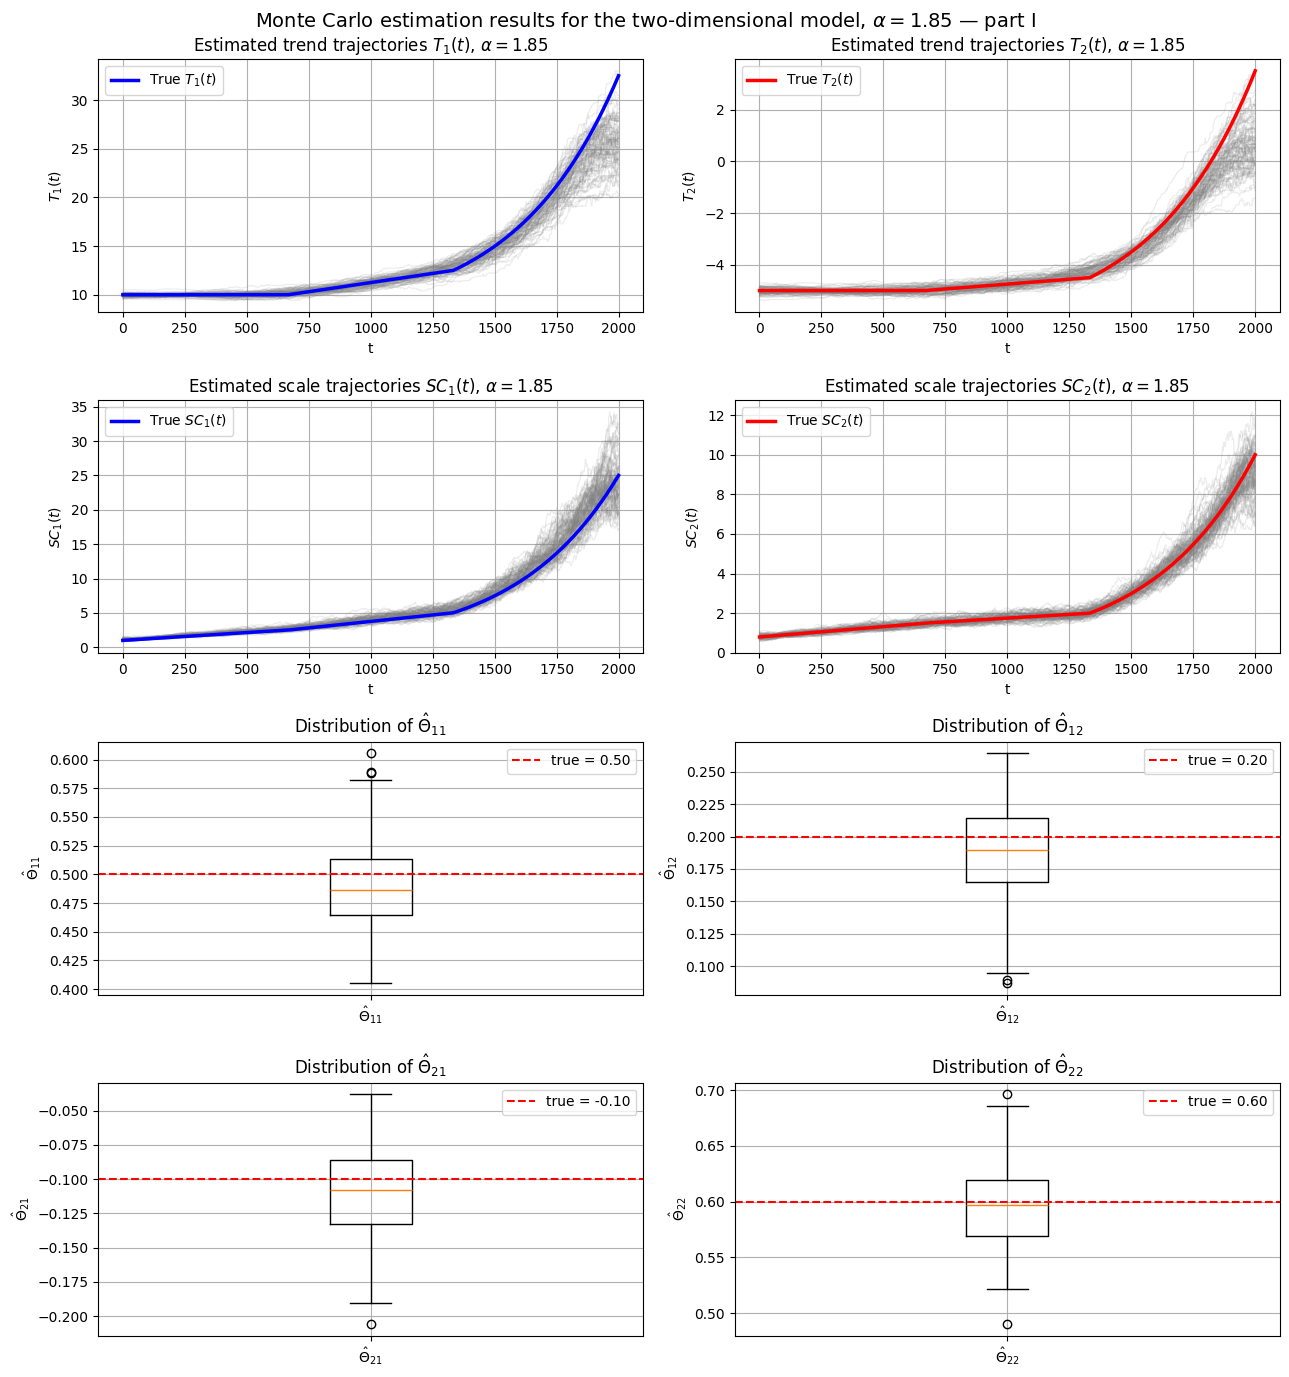

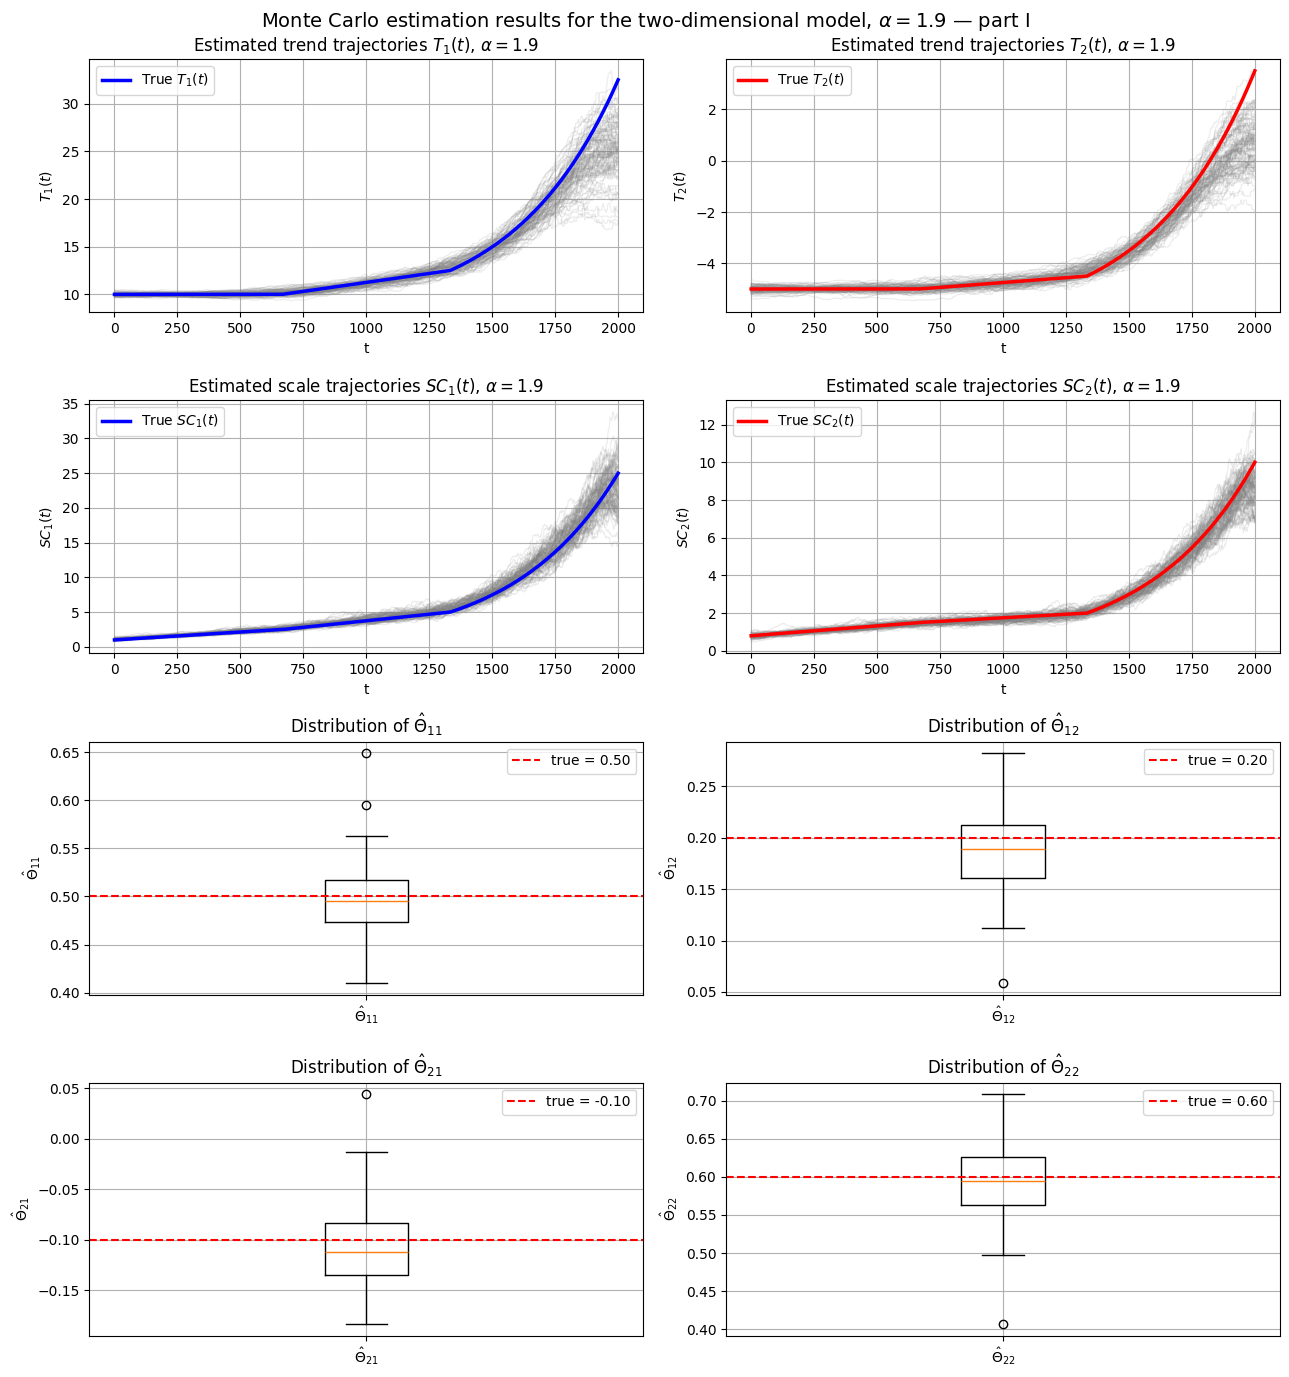

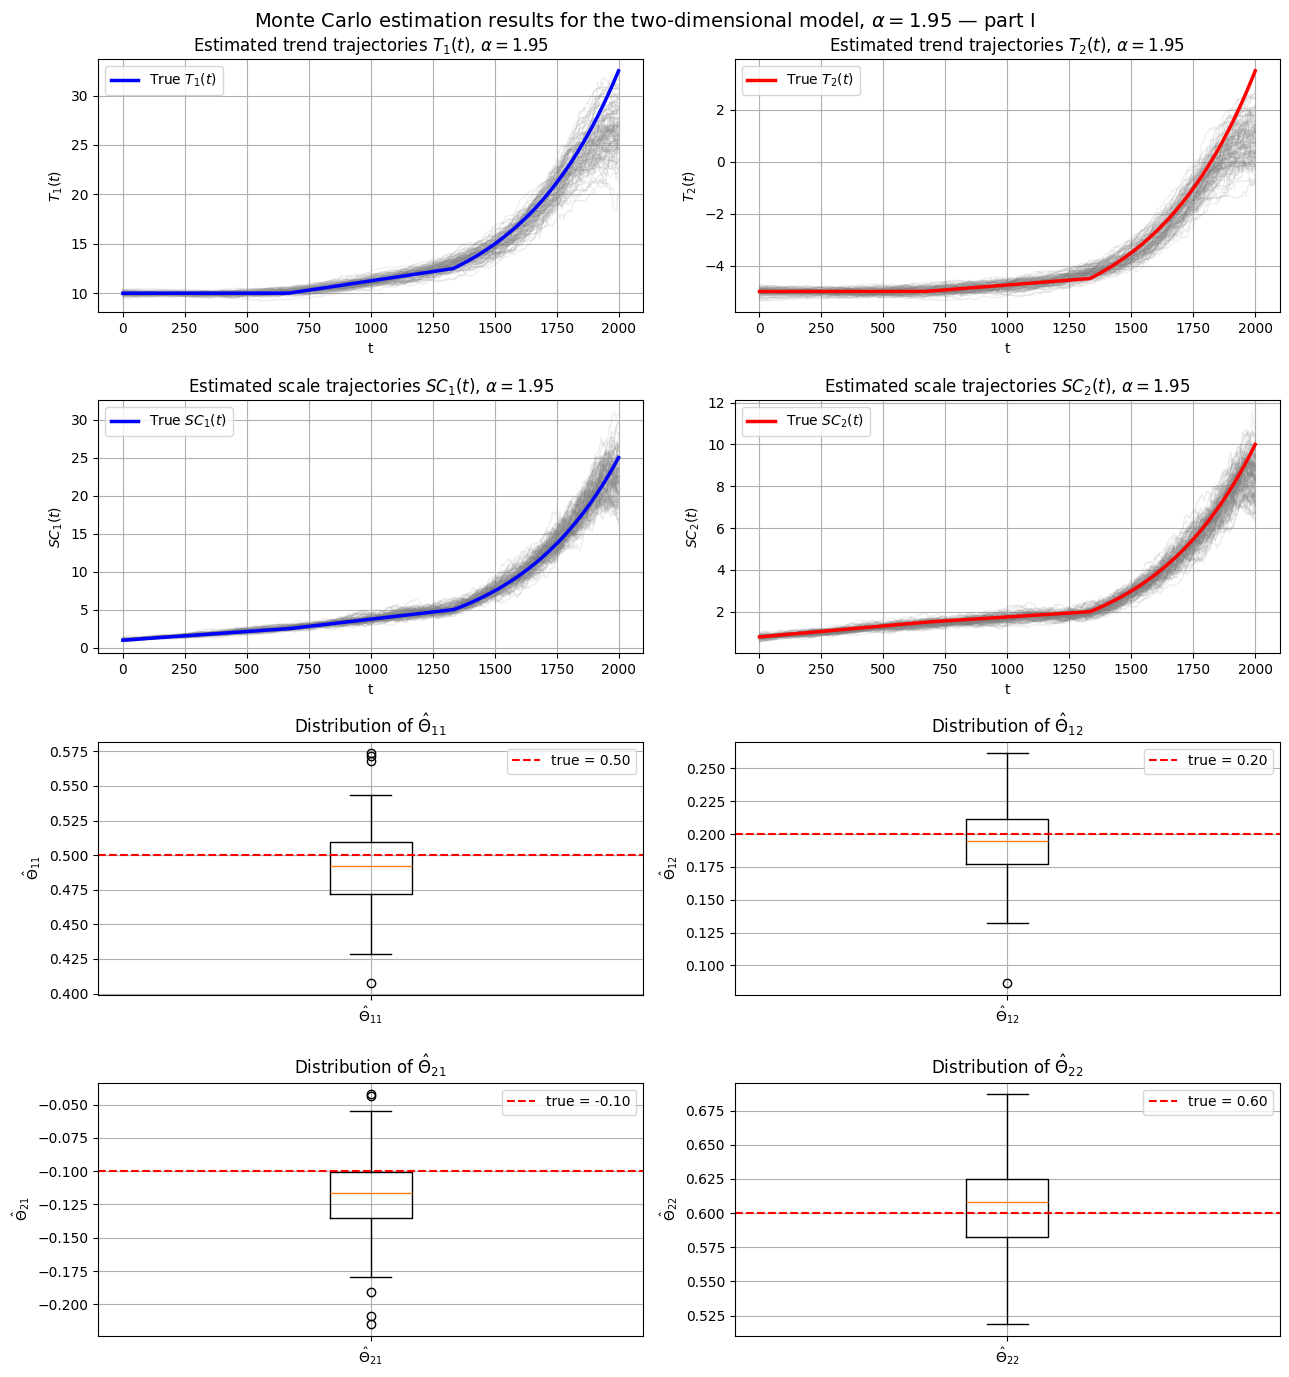

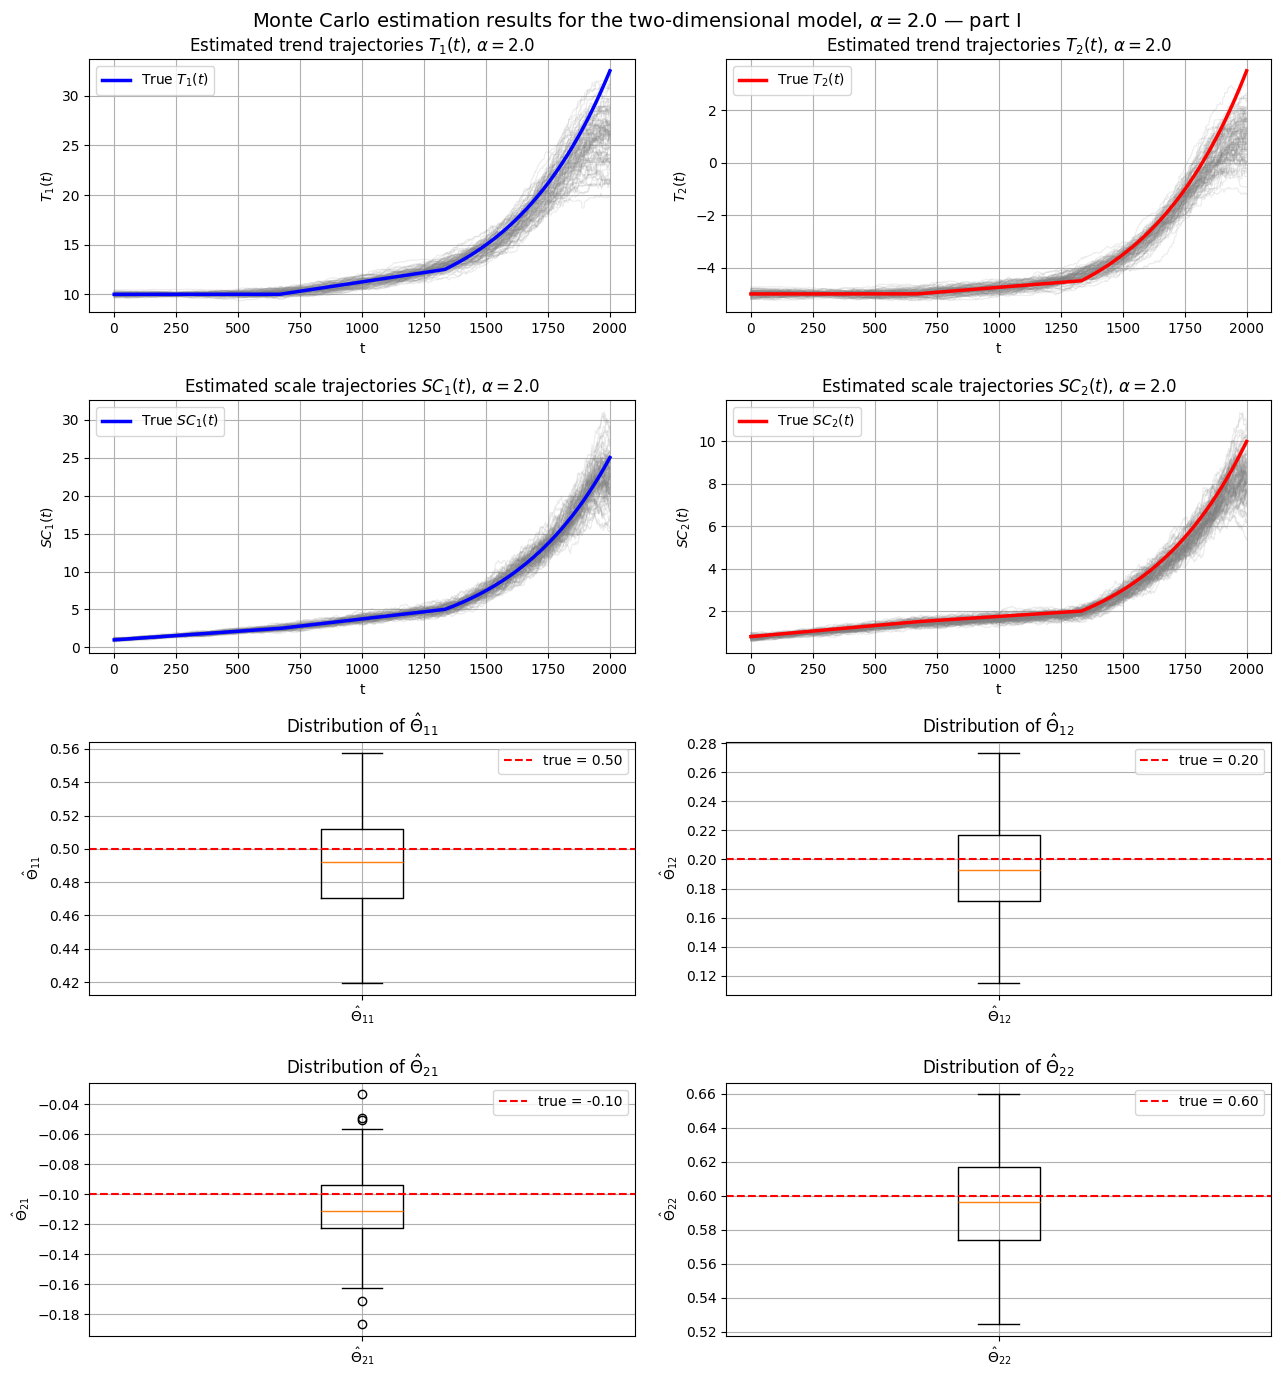

In [187]:
for alpha in alphas_order_2d:
    plot_mc_2d_part1(mc_2d_final_scaled[alpha])

The representative diagnostics show that VAR(1) removes most lagged dependence. Cross-correlation at lag 0 can remain because the residual vector is allowed to have contemporaneous dependence through $\Sigma$.


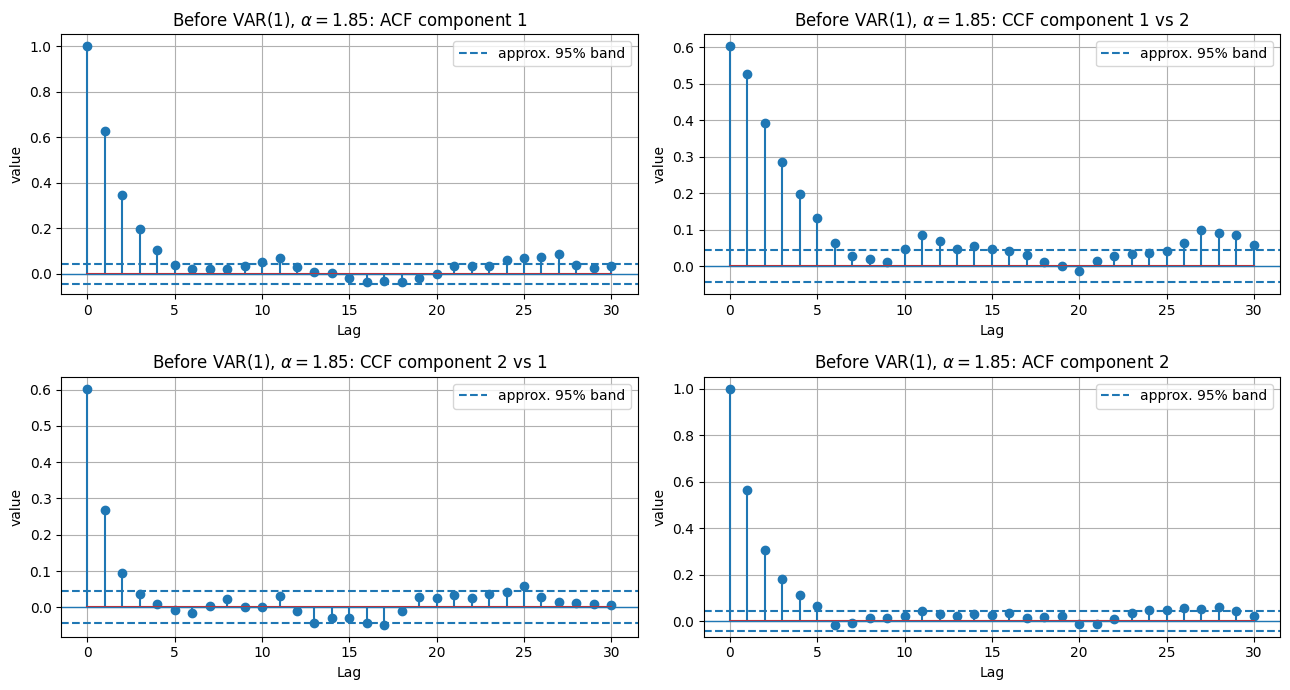

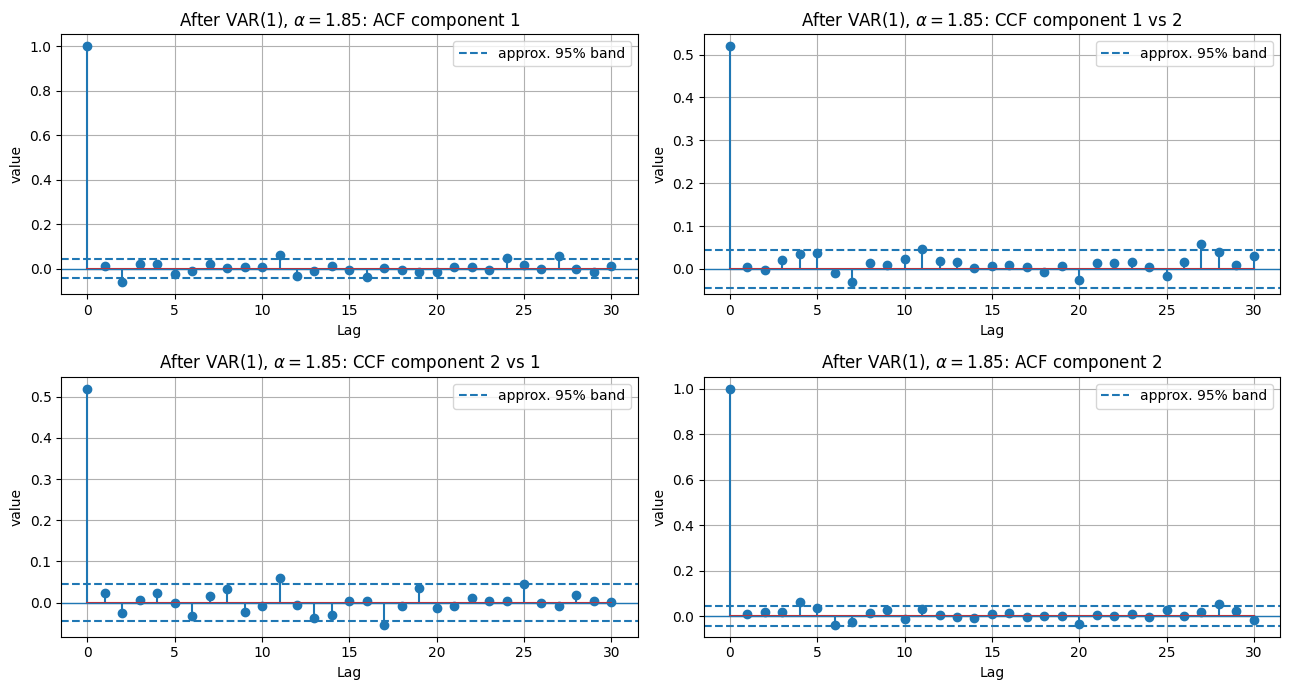

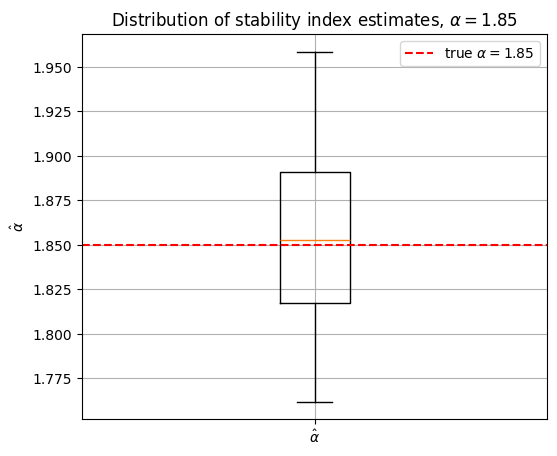

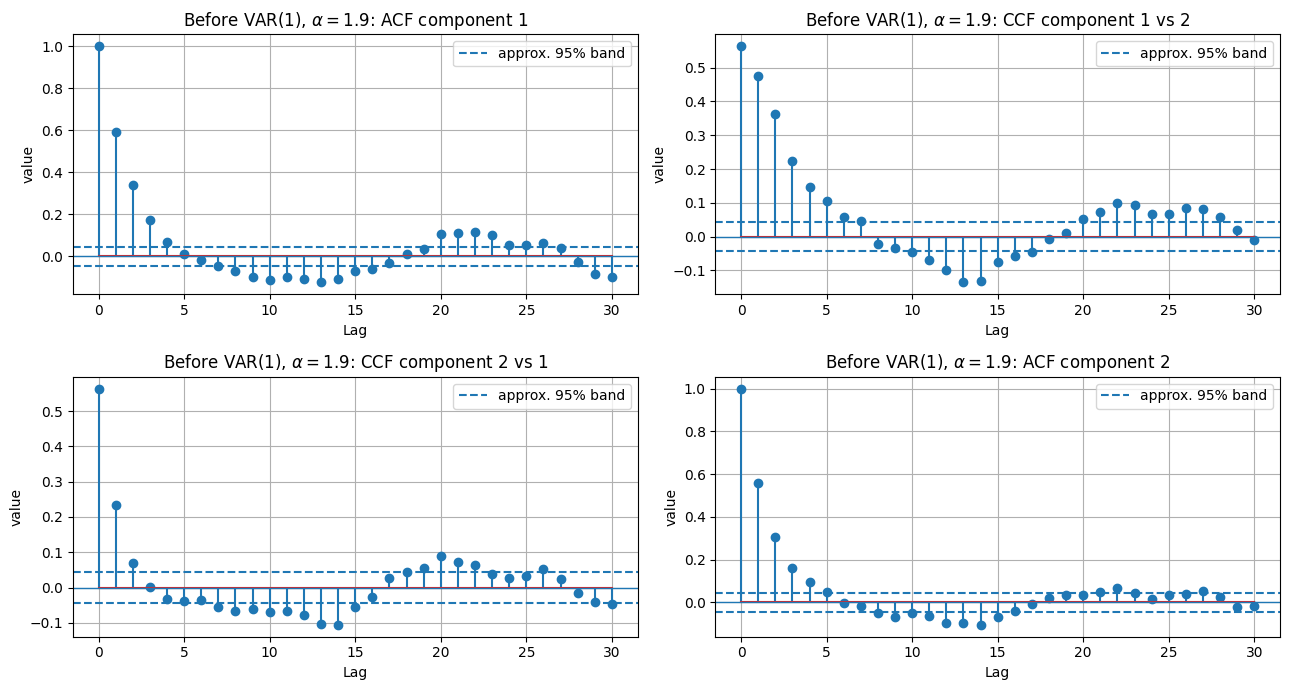

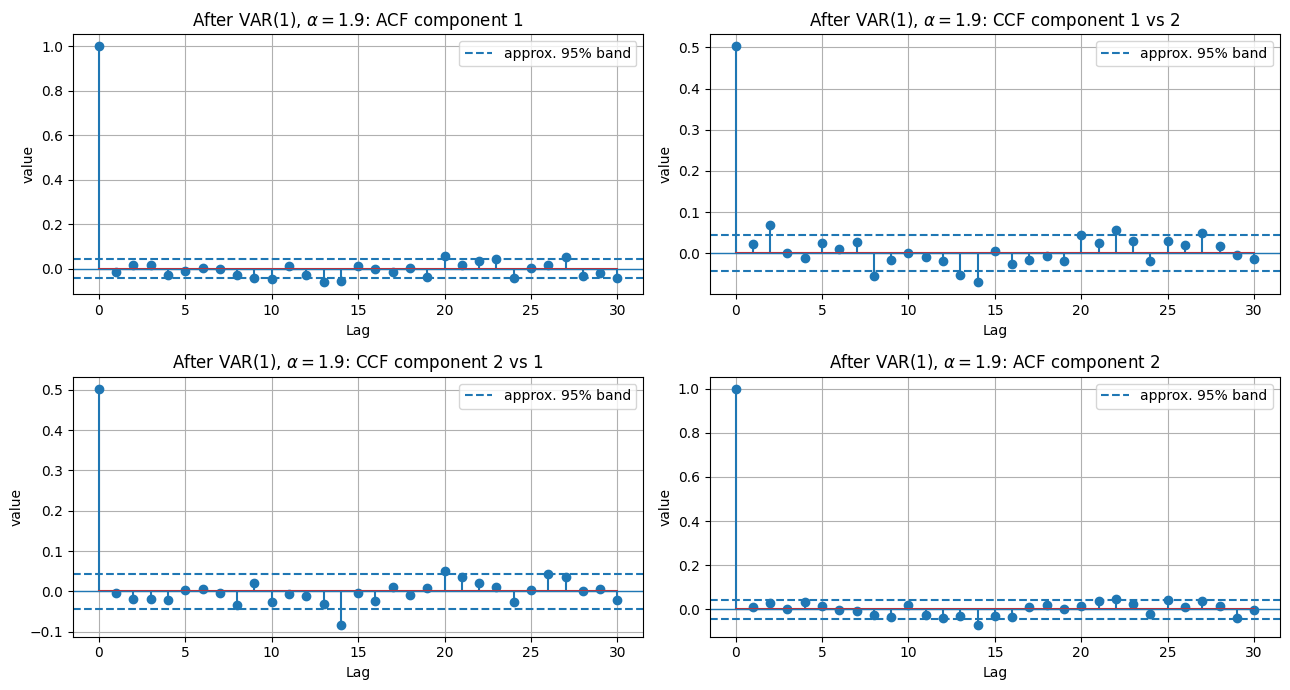

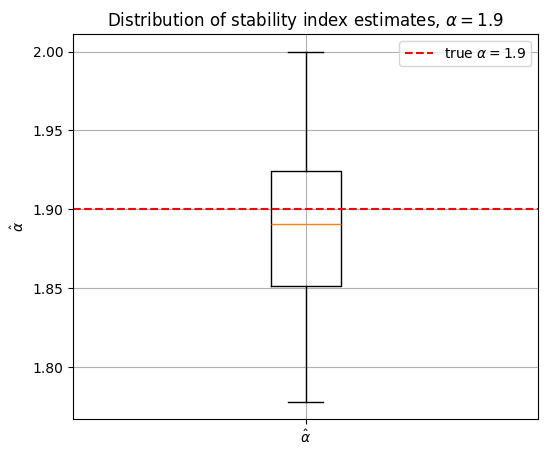

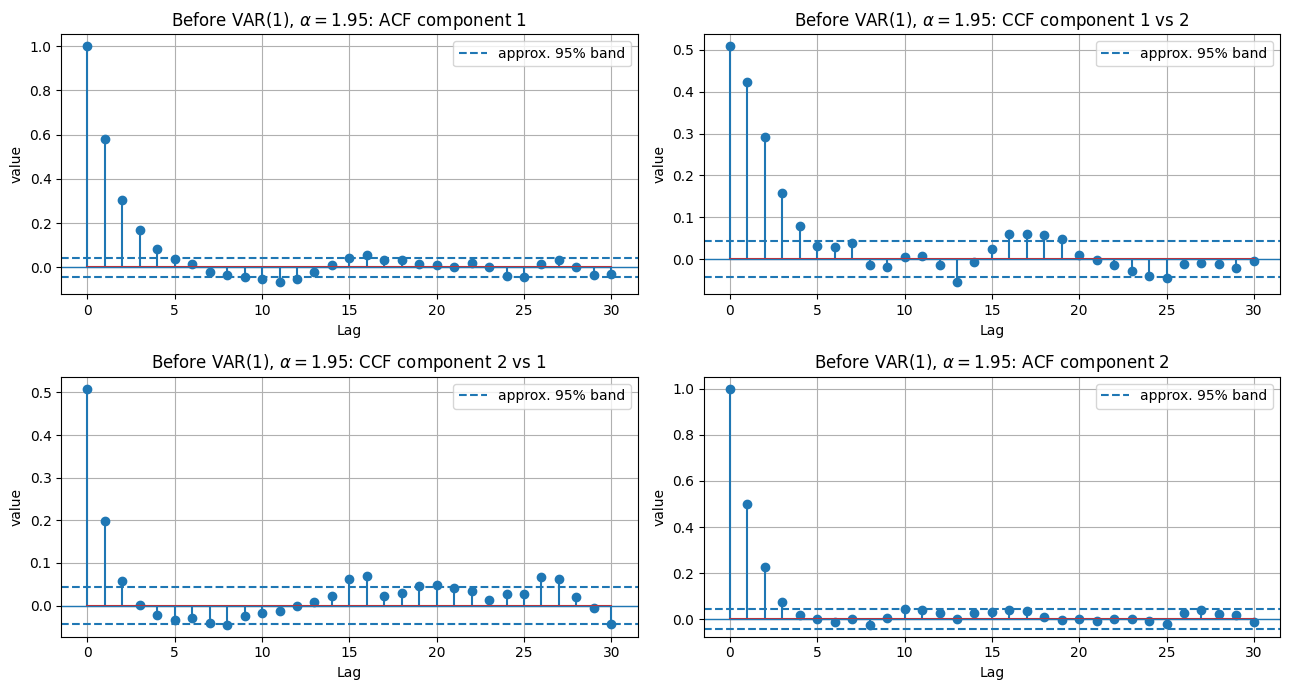

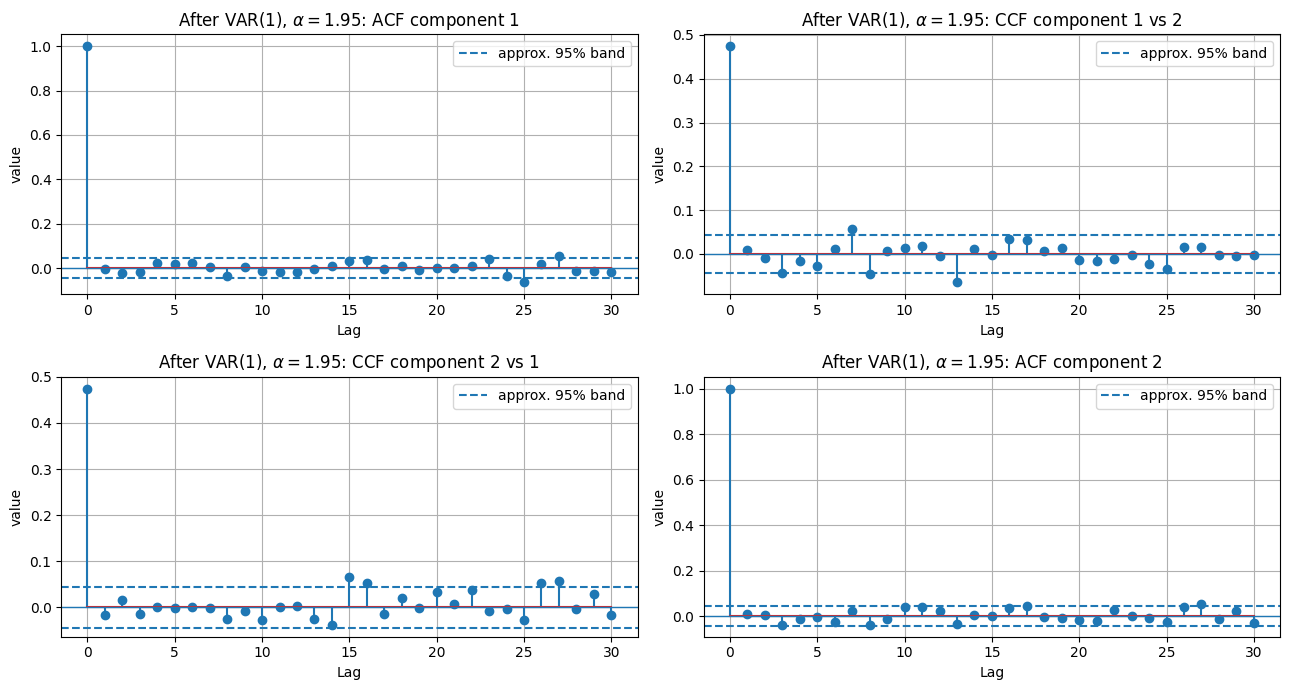

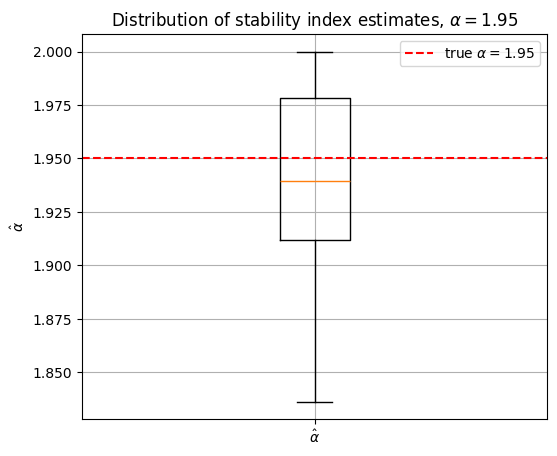

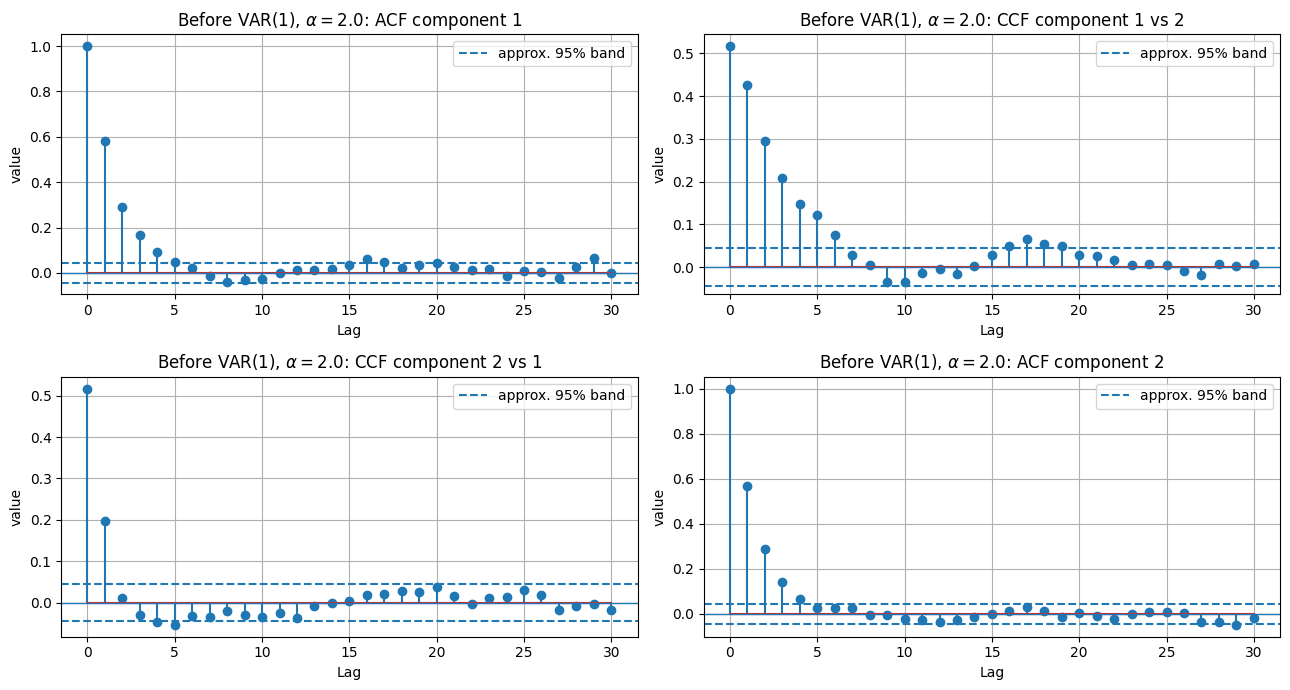

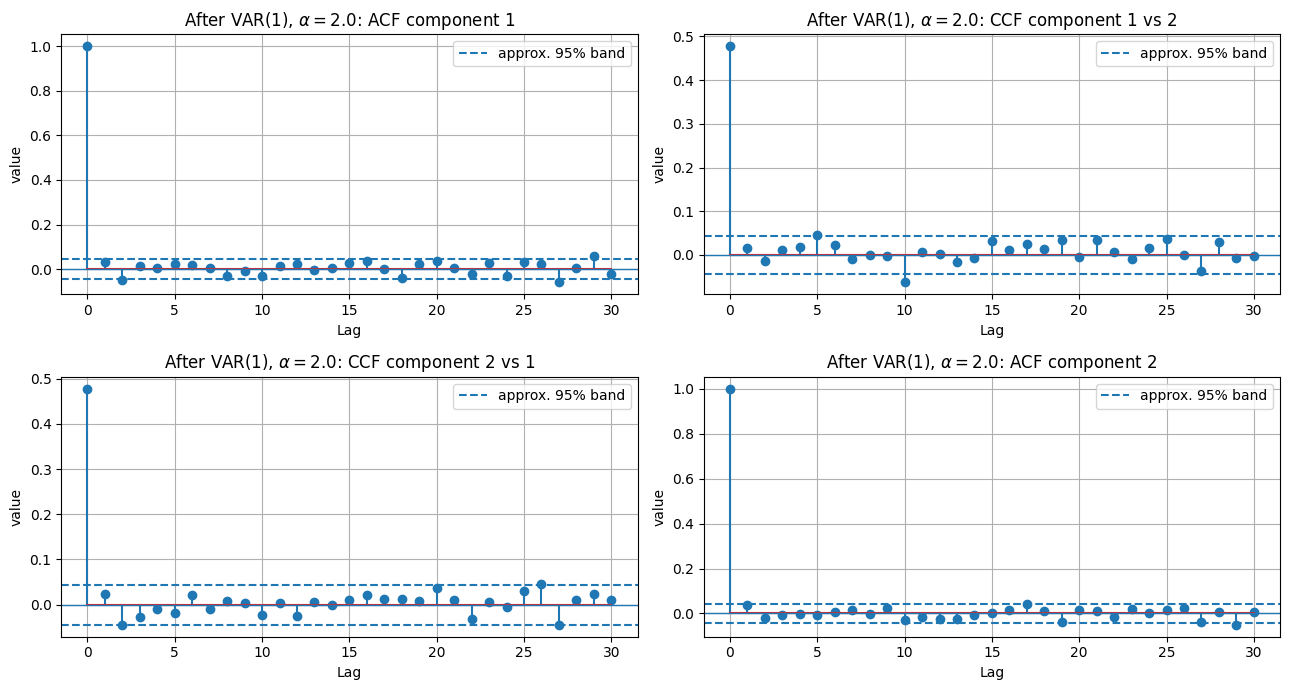

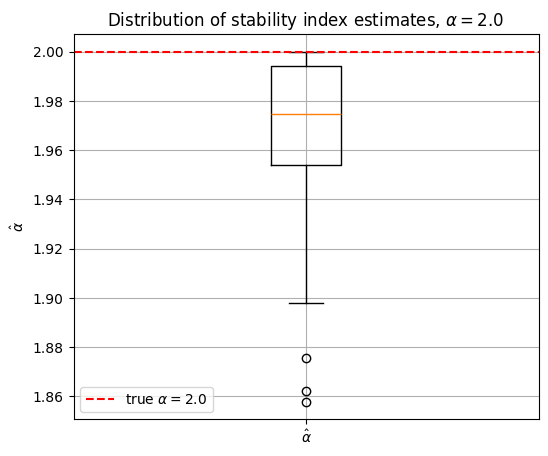

In [189]:
for alpha in alphas_order_2d:
    plot_mc_2d_part2(mc_2d_final_scaled[alpha])

The residual diagnostics after fitting the VAR(1) model indicate that the temporal dependence has been effectively removed. For both components, the robust ACF values at lags greater than zero are close to zero and mostly remain within the approximate 95% confidence bands. The same conclusion holds for the robust cross-correlation functions, which suggests that the fitted VAR(1) model adequately captures both within-component and cross-component linear dependence.

The boxplot of the stability-index estimates shows that the estimator recovers the true value of $\alpha$ reasonably well. A slight downward bias is still visible, but the estimates remain concentrated around the true parameter value.

## Estimation of the 2D Dependence Matrix $\Sigma$

The matrix $\Sigma$ describes contemporaneous dependence of the two-dimensional sub-Gaussian innovation vector. It is estimated from VAR residuals using the empirical characteristic function. Because this estimation is performed after trend estimation, scale normalization and VAR fitting, it is sensitive to scale reconstruction.

For the final simulation report we present the calibrated, scale-adjusted Monte Carlo version. The raw diagnostic Sigma plots used during development are omitted from the report; the limitation is mentioned briefly in the discussion.


In [198]:
n_replications_2d_sigma = 100

mc_2d_final_sigma = {}

for idx, alpha in enumerate(alphas_order_2d):
    print(f"Running 2D Monte Carlo with Sigma estimation for alpha={alpha}...")
    mc_2d_final_sigma[alpha] = run_mc_2d_for_alpha(
        alpha=alpha,
        base_params_2d=base_params_2d,
        n_replications=n_replications_2d_sigma,
        base_seed=40_000 + idx * 10_000,
        trend_window=501,
        scale_window=151,
        scale_multiplier=scale_multiplier_2d,
        estimate_sigma=True,
    )

print("Done.")

Running 2D Monte Carlo with Sigma estimation for alpha=1.85...
Running 2D Monte Carlo with Sigma estimation for alpha=1.9...
Running 2D Monte Carlo with Sigma estimation for alpha=1.95...
Running 2D Monte Carlo with Sigma estimation for alpha=2.0...
Done.


## **CHCEMY POKAZYWAC TE ADJUSTMENTS? - TO JEST KRZYWE**

### Final Scale-Adjusted $\Sigma$ Estimates

In synthetic simulations the true scale functions are known. We therefore apply a simulation-only scale adjustment based on the median ratio between estimated and true scale functions, and report the adjusted $\Sigma$ estimates as the final Sigma validation result. This correction is not directly available for real data, where the true scale is unknown.


In [ ]:
mc_2d_final_sigma = add_scale_adjusted_sigma(
    mc_2d_final_sigma,
    alphas_order_2d,
    trim_edges=100,
)


In [ ]:
scale_ratio_2d_final = scale_ratio_2d_summary(
    mc_2d_final_sigma,
    alphas_order_2d,
    trim_edges=100,
)

scale_ratio_2d_final

In [ ]:
mc_2d_sigma_adjusted_summary = adjusted_sigma_summary(
    mc_2d_final_sigma,
    alphas_order_2d,
    Sigma_true,
)
mc_2d_sigma_adjusted_summary


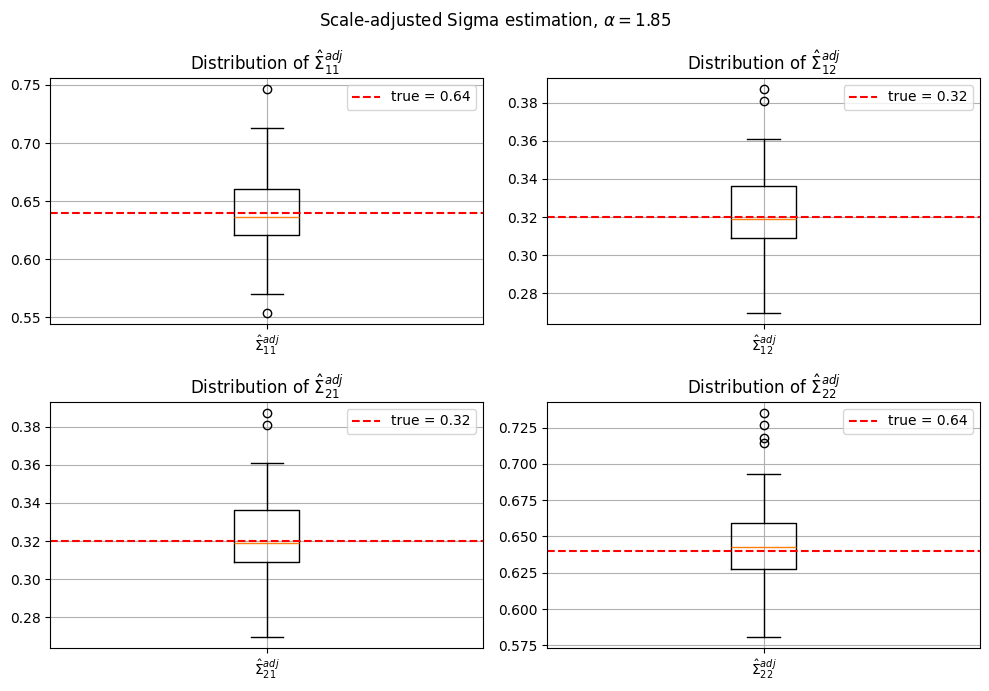

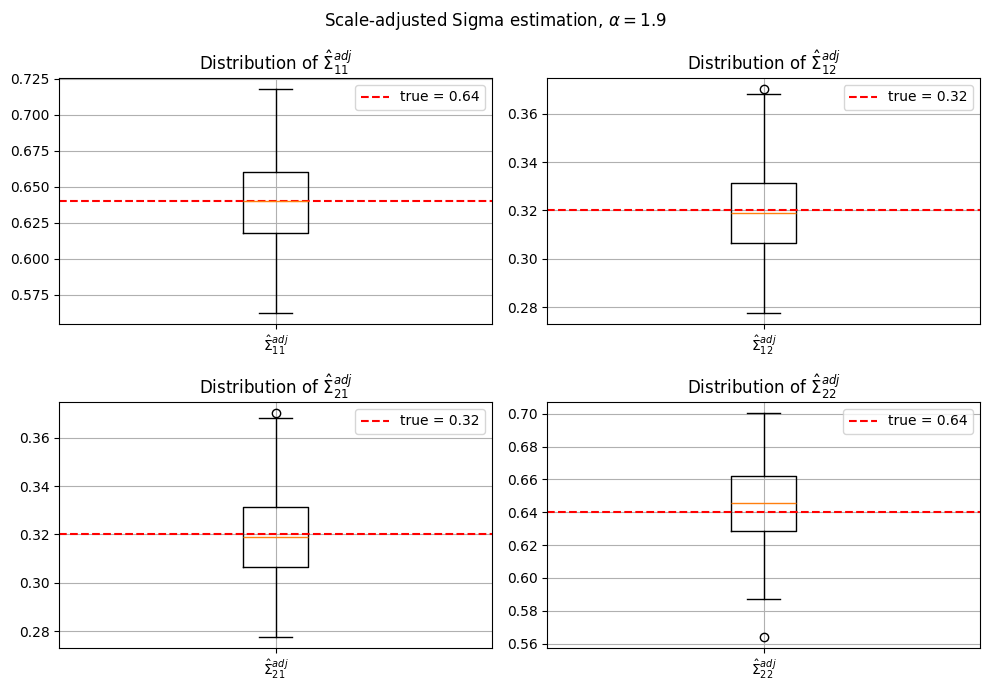

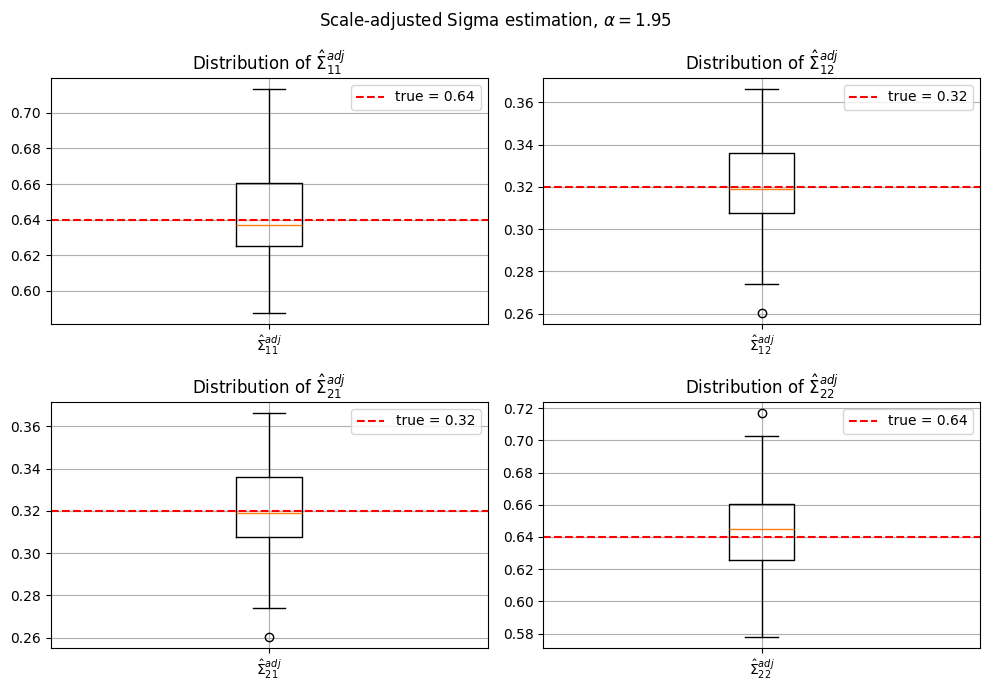

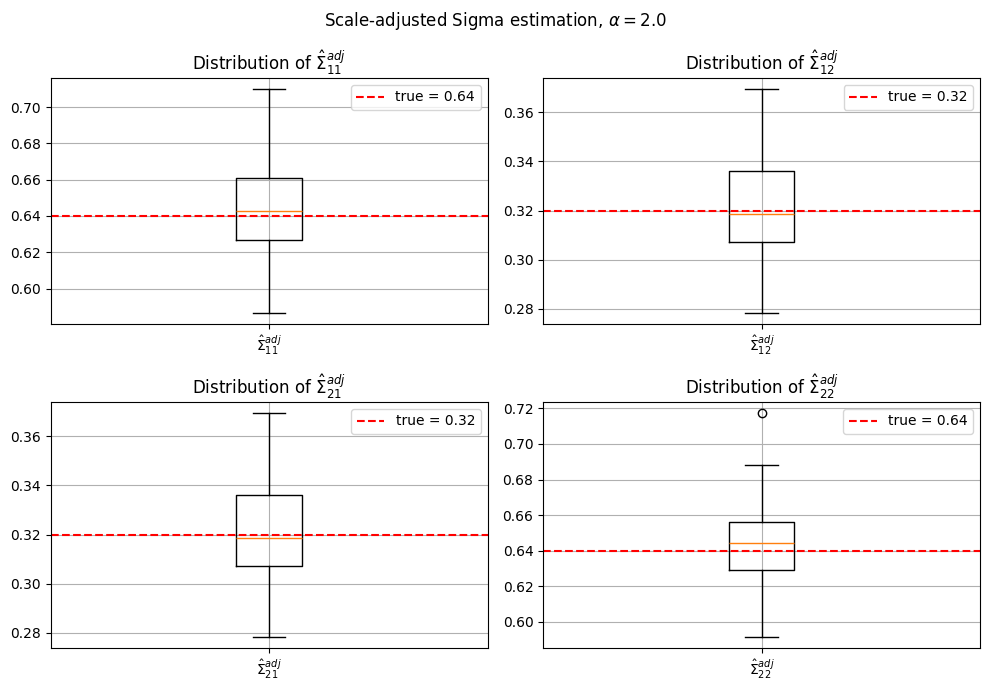

In [214]:
for alpha in alphas_order_2d:
    plot_sigma_boxplots_adjusted(mc_2d_final_sigma[alpha])

The adjusted estimates are much closer to the true $\Sigma$ values, especially for the off-diagonal entries. This supports the interpretation that the characteristic-function estimator captures contemporaneous dependence, while raw diagonal bias is largely driven by scale reconstruction error.


### **NIE ROZUMIEM PUNKTU 3, PUNKT 4 JEST DO DUPY BO W ZASADZIE MOWI ZE METODOLOGIA NIE DZIALA (MOZNA EWENTULANIE WSPOMNIEC O TYCH ADJUSTMENTS DO SKALI, BO METODA MCCULLOCHA JEST NIEWRAZLIWA NA SKALE)**

## Simulation Limitations and Diagnostic Corrections

The simulation study confirms that the model and estimation pipeline are internally consistent, but several points should be treated carefully:

- the robust trend and scale windows affect the AR/VAR parameter estimates; diagnostic window checks were used to choose the final 1D trend window of 501 and scale window of 151,
- $\alpha$ is constrained by the model to be at most 2, so boxplots for $\alpha=2$ may look clipped at the upper boundary,
- direct alpha estimation from simulated 2D innovations, when used, should be interpreted only as a diagnostic of the McCulloch-type alpha estimator itself, not as a full validation of the complete trend-scale-VAR pipeline,
- $\Sigma$ estimates are sensitive to scale reconstruction; the scale-adjusted version is possible only in simulations where the true scale is known,
- the real-data section below is therefore treated as a separate empirical validation step, with explicit notes about preprocessing, reference change points and cached bootstrap diagnostics.

### **TO JEST SPOKO OPROCZ OSTATNIEGO ZDANIA**

## Simulation Conclusions

The one-dimensional and two-dimensional simulation procedures produce health-index trajectories with the expected three-stage degradation structure. The estimation pipeline recovers the deterministic trend, time-varying scale and dependence parameters with acceptable accuracy in the Monte Carlo experiments.

In the 1D model, AR(1) fitting removes most temporal dependence from the normalized component. In the 2D model, VAR(1) plays the same role for both components and their lagged cross-dependence. Robust estimators are necessary throughout the procedure because alpha-stable and sub-Gaussian innovations can generate heavy-tailed, impulsive observations.

The main methodological caution concerns $\Sigma$: scale-adjusted validation is available in simulations because the true scale is known. In real data the dependence matrix must be interpreted together with trend, scale and residual diagnostics.

## **TU SA JAKIES BZDURY, Z TYM REFERENCE ANALYSIS, ZMIENIC NAZWE DANYCH NA ANG, WYJEBAC RAFAL XD, O TYM TRIMMOWANIU MOZNA NAPISAC ZE USUNELISMY PEIRWSZE ILES OBSERWACJIK == KIEDY MASZYNA SIE ROZKRECALA DOPIERO**

## Real Data Analysis — IMS Bearing Dataset

This final section applies the modelling pipeline to real vibration data from the IMS Bearing Dataset, Set No. 1. The previous sections used synthetic data, where the trend, scale, autoregressive matrices and regime-change points were known by construction. In real data these objects must be estimated or taken from a documented reference analysis.

The main reference for this section is `references/dane_rzeczywiste.ipynb`. In that notebook, Rafał constructs an RMS-based two-dimensional health index for Bearing 1, trims the beginning of the chronological series, uses MIDAST/ChangeDetector for regime-change analysis, and then fits a VAR model to the normalized residual component.

The goal here is not to copy the whole reference notebook, but to reproduce the same workflow inside the current project structure and with the helper functions already used in this report.


### Loading IMS vibration files

IMS Set No. 1 consists of 2156 one-second vibration files. Each file contains 20480 vibration samples and eight channels. Bearing 1 corresponds to channels 0 and 1 in Python indexing.

The cell below first tries to load the cached RMS health index from `ims_set1_bearing1_rms_hi.csv`. If the cache is missing, it reads the raw files from `ims/1st_test/1st_test`, sorts them chronologically by the timestamp encoded in the file name, computes RMS values for channels 0 and 1, and saves the cache CSV.


In [2]:
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import estimation2d
import real_data_analysis

importlib.reload(estimation2d)
importlib.reload(real_data_analysis)

from estimation2d import estimate_2d_model_fixed_var_order
from real_data_analysis import (
    load_ims_bearing1_rms,
    prepare_trimmed_hi,
    try_midast_change_detection,
    moving_block_bootstrap_diagnostics_ci,
    simulate_varp_paths_from_estimate,
    quantile_band_coverage,
)

IMS_FOLDER = Path("ims/1st_test/1st_test")
IMS_CACHE = Path("ims_set1_bearing1_rms_hi.csv")

ims_hi_df, ims_metadata = load_ims_bearing1_rms(
    ims_folder=IMS_FOLDER,
    cache_path=IMS_CACHE,
    force_recompute=False,
)

real_data_available = not ims_hi_df.empty

ims_summary = pd.DataFrame([{
    "raw_folder": ims_metadata["ims_folder"],
    "cache_path": ims_metadata["cache_path"],
    "loaded_from": ims_metadata["loaded_from"],
    "raw_file_count": ims_metadata["raw_file_count"],
    "first_file_channels": ims_metadata["first_file_channels"],
    "first_file_rows": ims_metadata["first_file_rows"],
    "HI_shape": tuple(ims_hi_df[["S1", "S2"]].shape) if real_data_available else None,
    "first_timestamp": ims_hi_df["timestamp"].iloc[0] if real_data_available else None,
    "last_timestamp": ims_hi_df["timestamp"].iloc[-1] if real_data_available else None,
    "message": ims_metadata["message"],
}])

display(ims_summary)

if real_data_available:
    display(ims_hi_df.head())
    display(ims_hi_df.tail())
else:
    print("IMS data are not available. Set IMS_FOLDER to the correct path or provide ims_set1_bearing1_rms_hi.csv.")


,raw_folder,cache_path,loaded_from,raw_file_count,first_file_channels,first_file_rows,HI_shape,first_timestamp,last_timestamp,message
0,ims\1st_test\1st_test,ims_set1_bearing1_rms_hi.csv,cache,2156,8,20480,"(2156, 2)",2003-10-22 12:06:24,2003-11-25 23:39:56,Loaded RMS health index from cache CSV.


,t,filename,timestamp,S1,S2
0,0,2003.10.22.12.06.24,2003-10-22 12:06:24,0.124614,0.117493
1,1,2003.10.22.12.09.13,2003-10-22 12:09:13,0.123811,0.116833
2,2,2003.10.22.12.14.13,2003-10-22 12:14:13,0.125246,0.118384
3,3,2003.10.22.12.19.13,2003-10-22 12:19:13,0.125197,0.119005
4,4,2003.10.22.12.24.13,2003-10-22 12:24:13,0.125618,0.119688


,t,filename,timestamp,S1,S2
2151,2151,2003.11.25.16.07.32,2003-11-25 16:07:32,0.168639,0.154687
2152,2152,2003.11.25.23.13.21,2003-11-25 23:13:21,0.174975,0.157712
2153,2153,2003.11.25.23.19.56,2003-11-25 23:19:56,0.174571,0.157296
2154,2154,2003.11.25.23.29.56,2003-11-25 23:29:56,0.173471,0.159363
2155,2155,2003.11.25.23.39.56,2003-11-25 23:39:56,0.174181,0.157991


### RMS-based health index construction

For each one-second raw vibration segment, the RMS value is computed separately for channels 0 and 1. This turns the raw vibration files into a two-dimensional health index

$$
S(t)=(S_1(t),S_2(t)),
$$

where $S_1(t)$ and $S_2(t)$ describe two vibration directions/sensors for Bearing 1. RMS is used because it summarizes the average signal energy in each segment and is a common diagnostic feature in bearing condition monitoring.


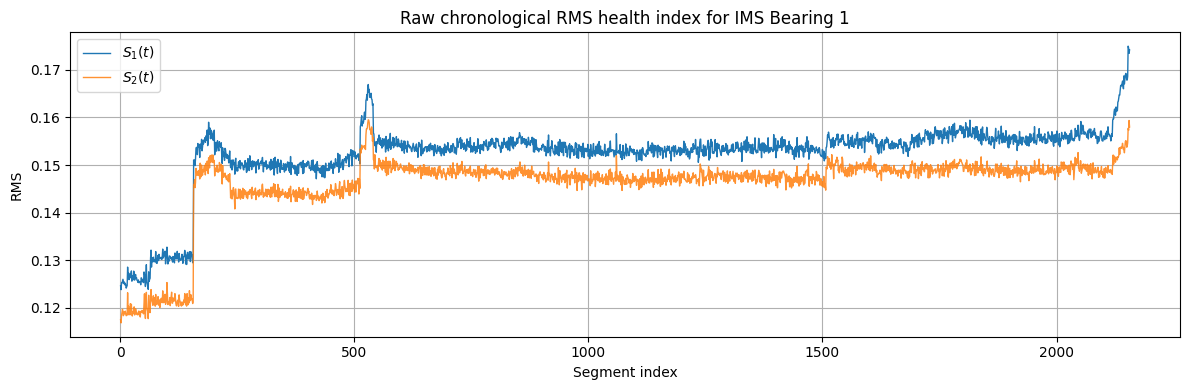

In [3]:
if real_data_available:
    raw_t = np.arange(1, len(ims_hi_df) + 1)

    plt.figure(figsize=(12, 4))
    plt.plot(raw_t, ims_hi_df["S1"], label=r"$S_1(t)$", linewidth=1)
    plt.plot(raw_t, ims_hi_df["S2"], label=r"$S_2(t)$", linewidth=1, alpha=0.85)
    plt.title("Raw chronological RMS health index for IMS Bearing 1")
    plt.xlabel("Segment index")
    plt.ylabel("RMS")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Raw HI plot skipped because IMS data are not available.")


## **GOWNO, NIEPOETRZEBNE**

### Preprocessing and alignment with Rafał's reference analysis

The reference notebook explicitly constructs the final HI as

```python
hi = np.array([rms_df["RMS Bearing 1"], rms_df["RMS Bearing 2"]])[:, 245:].T
```

Therefore, the reference-aligned real-data analysis starts from `start_index = 245` in the raw chronological RMS series. This removes an initial start-up/warm-up part of the run. An earlier visual suspicion suggested an offset near 252; the diagnostic comparison below keeps that alternative visible, but the pipeline follows the explicit reference notebook and uses `245`.

The regime-change points reported in the reference analysis are expressed on the trimmed time axis.


In [4]:
REFERENCE_START_INDEX = 245
DIAGNOSTIC_START_INDEX = 252

# Reference values from references/dane_rzeczywiste.ipynb, after trimming.
tau_ref = [268, 1262, 1873]
tau_ref_source = "reference value from Rafal's real-data analysis"

hi_real = np.empty((0, 2))
ims_trimmed_df = pd.DataFrame()
t_real = np.array([])

if real_data_available:
    hi_real, ims_trimmed_df = prepare_trimmed_hi(
        ims_hi_df,
        start_index=REFERENCE_START_INDEX,
    )
    hi_trim_252, ims_trimmed_252_df = prepare_trimmed_hi(
        ims_hi_df,
        start_index=DIAGNOSTIC_START_INDEX,
    )
    t_real = np.arange(1, len(hi_real) + 1)

    alignment_summary = pd.DataFrame([
        {
            "series": "raw chronological HI",
            "start_index": 0,
            "n_obs": len(ims_hi_df),
            "first_timestamp": ims_hi_df["timestamp"].iloc[0],
        },
        {
            "series": "reference-aligned HI",
            "start_index": REFERENCE_START_INDEX,
            "n_obs": len(hi_real),
            "first_timestamp": ims_trimmed_df["timestamp"].iloc[0],
        },
        {
            "series": "diagnostic alternative",
            "start_index": DIAGNOSTIC_START_INDEX,
            "n_obs": len(hi_trim_252),
            "first_timestamp": ims_trimmed_252_df["timestamp"].iloc[0],
        },
    ])
    display(alignment_summary)
else:
    print("Alignment skipped because IMS data are not available.")


,series,start_index,n_obs,first_timestamp
0,raw chronological HI,0,2156,2003-10-22 12:06:24
1,reference-aligned HI,245,1911,2003-10-31 01:49:46
2,diagnostic alternative,252,1904,2003-10-31 02:59:46


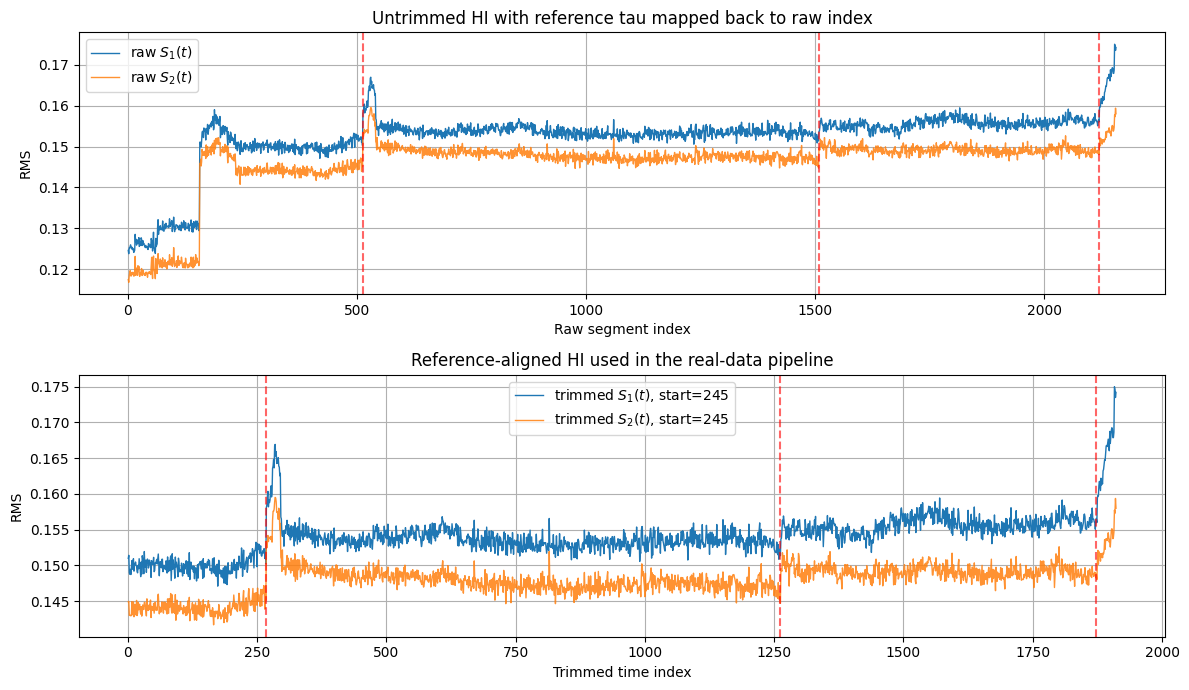

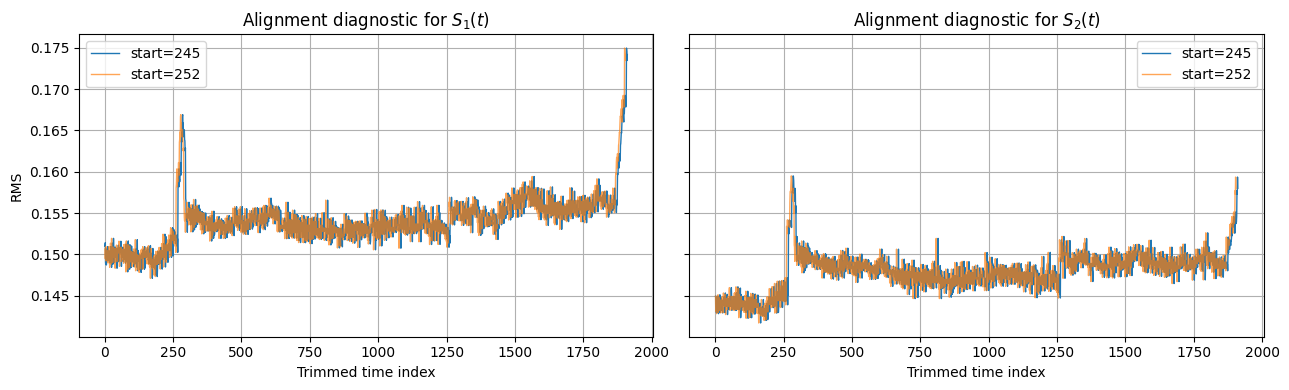

In [5]:
if real_data_available:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

    raw_axis = np.arange(1, len(ims_hi_df) + 1)
    axes[0].plot(raw_axis, ims_hi_df["S1"], label=r"raw $S_1(t)$", linewidth=1)
    axes[0].plot(raw_axis, ims_hi_df["S2"], label=r"raw $S_2(t)$", linewidth=1, alpha=0.85)
    for tau in tau_ref:
        axes[0].axvline(REFERENCE_START_INDEX + tau, color="red", linestyle="--", alpha=0.6)
    axes[0].set_title("Untrimmed HI with reference tau mapped back to raw index")
    axes[0].set_xlabel("Raw segment index")
    axes[0].set_ylabel("RMS")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, hi_real[:, 0], label=r"trimmed $S_1(t)$, start=245", linewidth=1)
    axes[1].plot(t_real, hi_real[:, 1], label=r"trimmed $S_2(t)$, start=245", linewidth=1, alpha=0.85)
    for tau in tau_ref:
        axes[1].axvline(tau, color="red", linestyle="--", alpha=0.6)
    axes[1].set_title("Reference-aligned HI used in the real-data pipeline")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].set_ylabel("RMS")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    axes[0].plot(np.arange(1, len(hi_real) + 1), hi_real[:, 0], label="start=245", linewidth=1)
    axes[0].plot(np.arange(1, len(hi_trim_252) + 1), hi_trim_252[:, 0], label="start=252", linewidth=1, alpha=0.7)
    axes[0].set_title(r"Alignment diagnostic for $S_1(t)$")
    axes[0].set_xlabel("Trimmed time index")
    axes[0].set_ylabel("RMS")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(np.arange(1, len(hi_real) + 1), hi_real[:, 1], label="start=245", linewidth=1)
    axes[1].plot(np.arange(1, len(hi_trim_252) + 1), hi_trim_252[:, 1], label="start=252", linewidth=1, alpha=0.7)
    axes[1].set_title(r"Alignment diagnostic for $S_2(t)$")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Alignment plots skipped because IMS data are not available.")


## **GOWNO KOMPLETNE, MOZNA TEN MIDAST POMINAC**

### Regime-change points and MIDAST reference

In simulations the change points are known because they are part of the data-generating mechanism. For real IMS data they must be detected from the observed HI. Rafał's reference notebook uses MIDAST/`ChangeDetector` with `KSTest`, `window_size=100`, `shift=2`, `alpha=0.1` and `shift_group=5`, and then sets the final reference change points to

$$
\tau_{ref}=(268,1262,1873).
$$

The code below tries to import and run the full MIDAST implementation. If the package is not present in this workspace, the notebook uses `tau_ref` as **reference values**, not as values estimated by our code.


In [6]:
midast_result = None
change_points_estimated = None
tau_used = tau_ref.copy()
tau_used_source = tau_ref_source

if real_data_available:
    midast_result = try_midast_change_detection(
        hi_real,
        search_roots=(Path("."), Path("references")),
        test_name="KSTest",
        window_size=100,
        shift=2,
        n_bkps=2,
        alpha=0.1,
        shift_group=5,
    )

    if midast_result["available"]:
        change_points_estimated = midast_result["change_points_estimated"]
        tau_used = change_points_estimated
        tau_used_source = "estimated value from available MIDAST ChangeDetector"
    else:
        print(midast_result["message"])
        print("TODO: Add full MIDAST implementation or include the missing MIDAST package in the repository.")

    change_point_summary = pd.DataFrame({
        "quantity": ["tau_ref", "change_points_estimated", "tau_used"],
        "value": [tau_ref, change_points_estimated, tau_used],
        "status": [tau_ref_source, "estimated value if MIDAST is available", tau_used_source],
    })
    display(change_point_summary)
else:
    print("Change-point analysis skipped because IMS data are not available.")


Full MIDAST implementation is not available in the current workspace. Therefore, reference regime-change points are used.
TODO: Add full MIDAST implementation or include the missing MIDAST package in the repository.


,quantity,value,status
0,tau_ref,"[268, 1262, 1873]",reference value from Rafal's real-data analysis
1,change_points_estimated,None,estimated value if MIDAST is available
2,tau_used,"[268, 1262, 1873]",reference value from Rafal's real-data analysis


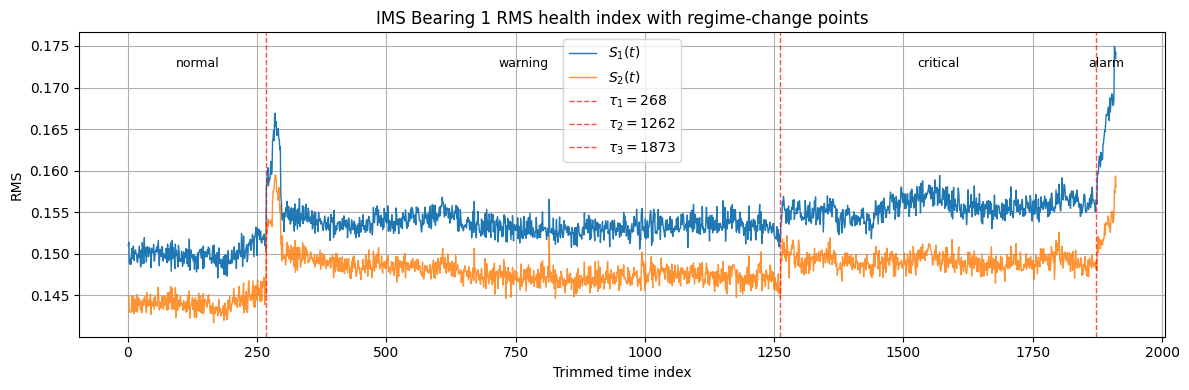

In [7]:
if real_data_available:
    plt.figure(figsize=(12, 4))
    plt.plot(t_real, hi_real[:, 0], label=r"$S_1(t)$", linewidth=1)
    plt.plot(t_real, hi_real[:, 1], label=r"$S_2(t)$", linewidth=1, alpha=0.85)
    add_regime_annotations(plt.gca(), tau_used, len(hi_real))
    plt.title("IMS Bearing 1 RMS health index with regime-change points")
    plt.xlabel("Trimmed time index")
    plt.ylabel("RMS")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Regime plot skipped because IMS data are not available.")


### Trend and scale estimation

The real-data estimation follows the 2D model logic from the synthetic part, but uses the parameter settings from the reference workflow:

- trend window: 101,
- scale window: 51,
- VAR order: $p=6$,
- ACF/CCF maximum lag: 20.

The trend describes the slowly varying degradation level. After subtracting it, the scale function estimates the local volatility of the remaining random component. Both steps are robust because the bearing signal contains impulses and heavy-tailed fluctuations.


In [8]:
REAL_TREND_WINDOW = 101
REAL_SCALE_WINDOW = 51
REAL_VAR_ORDER = 6
REAL_H_MAX = 20
REAL_DATA_ESTIMATE_SIGMA = True

real_est = None

if real_data_available:
    real_est = estimate_2d_model_fixed_var_order(
        hi_real,
        p=REAL_VAR_ORDER,
        trend_window=REAL_TREND_WINDOW,
        scale_window=REAL_SCALE_WINDOW,
        h_max=REAL_H_MAX,
        compute_diagnostics=True,
        estimate_sigma=REAL_DATA_ESTIMATE_SIGMA,
        sigma_grid_size=7,
        sigma_grid_max=3.0,
        sigma_maxiter=300,
    )

    display(pd.DataFrame([real_est["settings"]]))
else:
    print("Real-data estimation skipped because IMS data are not available.")


,trend_window,scale_window,h_max,compute_diagnostics,var_order,scale_multiplier,estimate_sigma,sigma_grid_size,sigma_grid_max
0,101,51,20,True,6,1.0,True,7,3.0


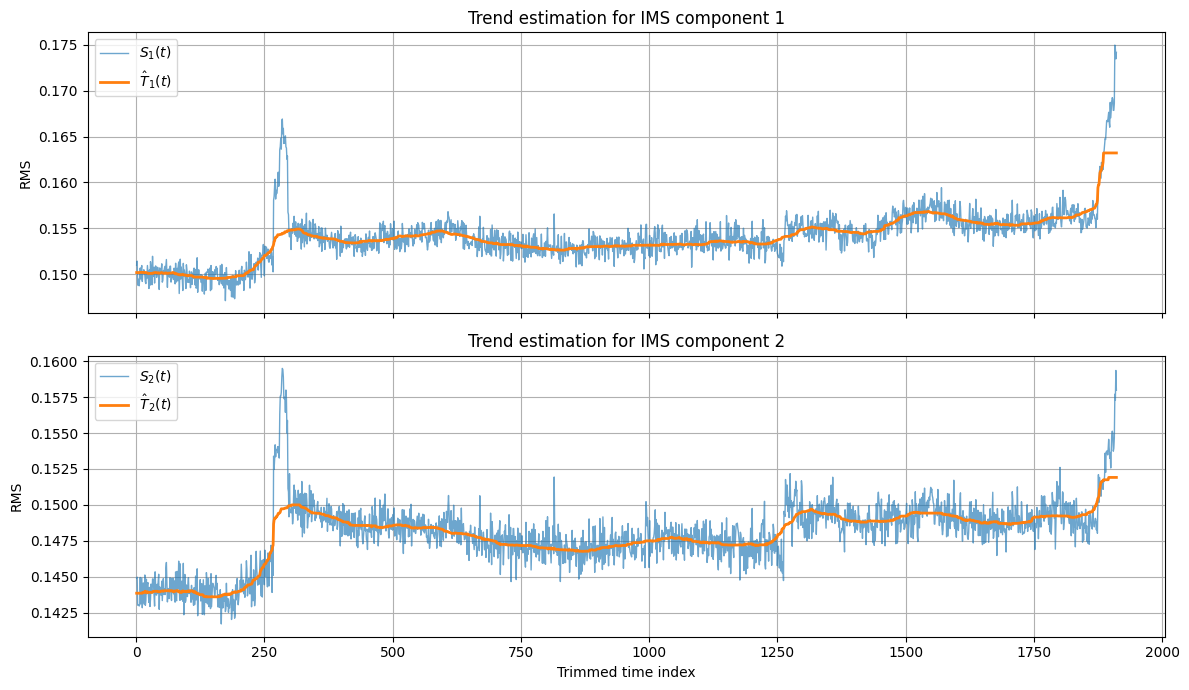

In [9]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, hi_real[:, 0], label=r"$S_1(t)$", linewidth=1, alpha=0.65)
    axes[0].plot(t_real, real_est["T_hat"][:, 0], label=r"$\hat T_1(t)$", linewidth=2)
    axes[0].set_title("Trend estimation for IMS component 1")
    axes[0].set_ylabel("RMS")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, hi_real[:, 1], label=r"$S_2(t)$", linewidth=1, alpha=0.65)
    axes[1].plot(t_real, real_est["T_hat"][:, 1], label=r"$\hat T_2(t)$", linewidth=2)
    axes[1].set_title("Trend estimation for IMS component 2")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].set_ylabel("RMS")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Trend plot skipped because real_est is not available.")


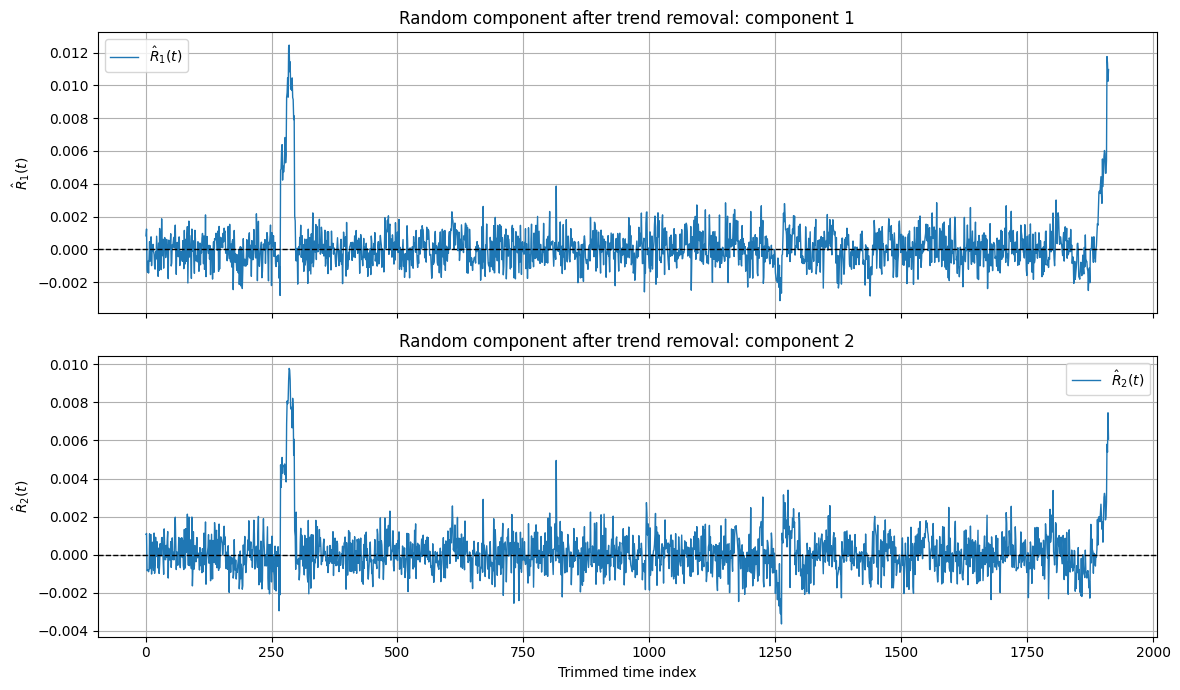

In [10]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, real_est["R_hat"][:, 0], label=r"$\hat R_1(t)$", linewidth=1)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Random component after trend removal: component 1")
    axes[0].set_ylabel(r"$\hat R_1(t)$")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, real_est["R_hat"][:, 1], label=r"$\hat R_2(t)$", linewidth=1)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Random component after trend removal: component 2")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].set_ylabel(r"$\hat R_2(t)$")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Random-component plot skipped because real_est is not available.")


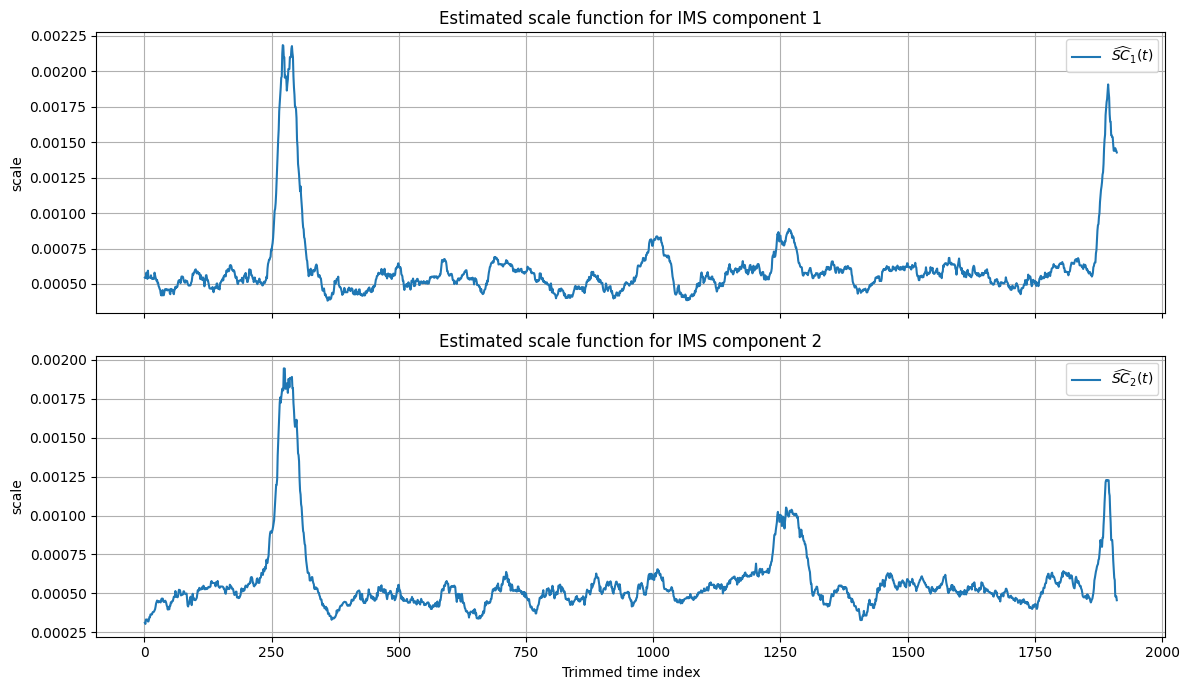

In [11]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, real_est["SC_hat"][:, 0], label=r"$\widehat{SC}_1(t)$", linewidth=1.5)
    axes[0].set_title("Estimated scale function for IMS component 1")
    axes[0].set_ylabel("scale")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, real_est["SC_hat"][:, 1], label=r"$\widehat{SC}_2(t)$", linewidth=1.5)
    axes[1].set_title("Estimated scale function for IMS component 2")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].set_ylabel("scale")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Scale plot skipped because real_est is not available.")


## **WYTLUMACZYC DLACZEGO P=6 ZOSTALO WYBRANE, BO WIDAC OKRESOWOSC O OKRESIE 3 I PROBOWALISMY 3,6,9,12, ITD. I 6 NAJLEPIEJ USUWAL ZALEZNOSCI**

### Normalization and VAR(6) residual modelling

The normalized signal

$$
\hat R2_i(t)=\hat R_i(t)/\widehat{SC}_i(t)
$$

should be closer to a stationary vector time series. A VAR(6) model is then fitted to remove lagged temporal dependence and cross-component lagged dependence. The residuals $\hat R3(t)$ are interpreted as estimated innovations of the real-data model.


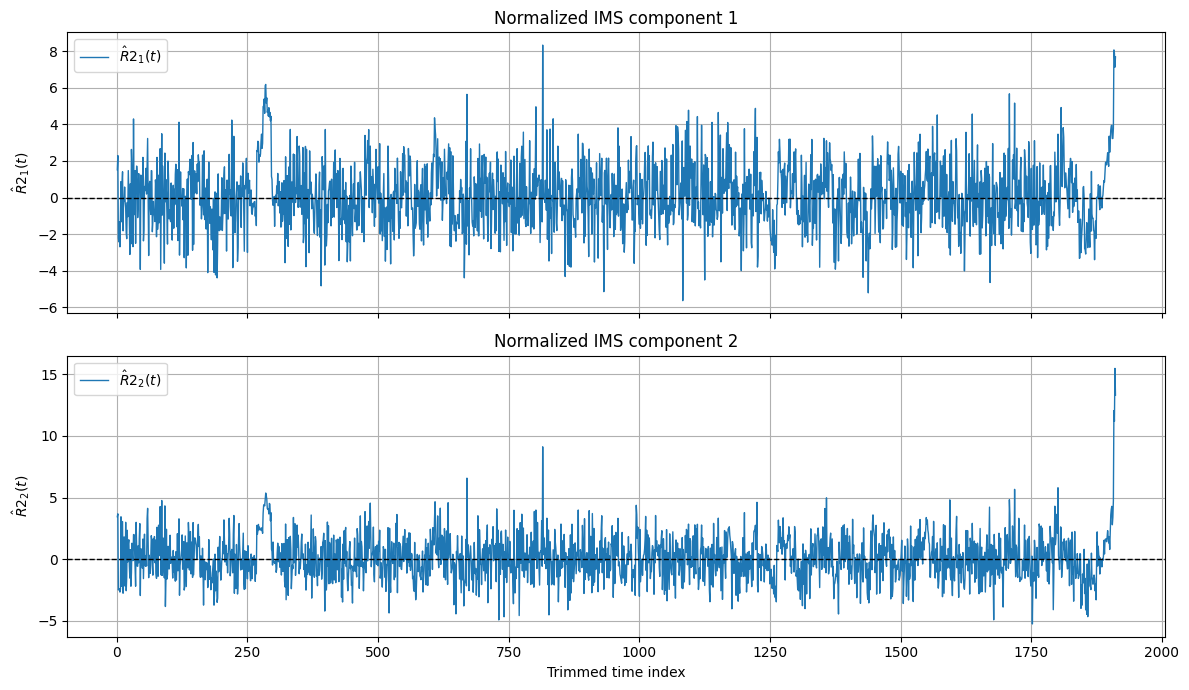

In [12]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, real_est["R2_hat"][:, 0], label=r"$\hat R2_1(t)$", linewidth=1)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Normalized IMS component 1")
    axes[0].set_ylabel(r"$\hat R2_1(t)$")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, real_est["R2_hat"][:, 1], label=r"$\hat R2_2(t)$", linewidth=1)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Normalized IMS component 2")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].set_ylabel(r"$\hat R2_2(t)$")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Normalized-signal plot skipped because real_est is not available.")


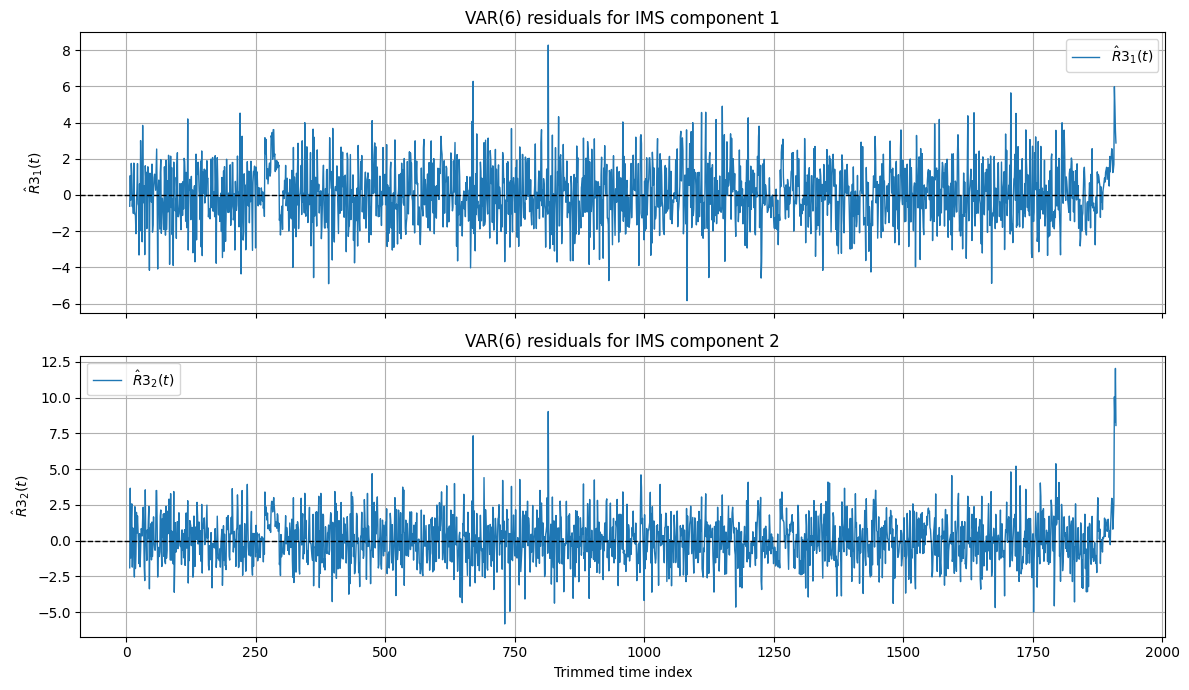

In [13]:
if real_est is not None:
    t_res = np.arange(REAL_VAR_ORDER + 1, len(hi_real) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_res, real_est["R3_hat"][:, 0], label=r"$\hat R3_1(t)$", linewidth=1)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("VAR(6) residuals for IMS component 1")
    axes[0].set_ylabel(r"$\hat R3_1(t)$")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_res, real_est["R3_hat"][:, 1], label=r"$\hat R3_2(t)$", linewidth=1)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("VAR(6) residuals for IMS component 2")
    axes[1].set_xlabel("Trimmed time index")
    axes[1].set_ylabel(r"$\hat R3_2(t)$")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Residual plot skipped because real_est is not available.")


### Robust ACF/CCF diagnostics

The robust ACF/CCF plots diagnose whether normalization and VAR(6) modelling remove serial dependence. Before VAR(6), the normalized component can still show lagged dependence. After VAR(6), ACF and CCF values at positive lags should be closer to zero. Lag 0 cross-correlation is not expected to vanish completely, because contemporaneous dependence belongs to the innovation distribution and is described by $\Sigma$.

Moving Block Bootstrap confidence intervals are handled by cache. The default report settings are `RUN_MBB_BOOTSTRAP = False`, `USE_CACHED_MBB = True` and `MBB_REPS = 200`. If `real_data_mbb_ci_VAR6_h20_B200.pkl` is present, it is loaded. Bootstrap is recomputed only when explicitly requested; otherwise the notebook falls back to simple approximate bands.


In [ ]:
import pickle
from pathlib import Path

RUN_MBB_BOOTSTRAP = False
USE_CACHED_MBB = True
MBB_REPS = 200
MBB_CACHE = Path(f"real_data_mbb_ci_VAR{REAL_VAR_ORDER}_h{REAL_H_MAX}_B{MBB_REPS}.pkl")

ci_R2 = None
ci_R3 = None
mbb_status = "not available"

if real_est is not None and USE_CACHED_MBB and MBB_CACHE.exists():
    with open(MBB_CACHE, "rb") as f:
        cached_ci = pickle.load(f)

    ci_R2 = cached_ci["ci_R2"]
    ci_R3 = cached_ci["ci_R3"]
    mbb_status = f"loaded cached MBB confidence intervals from {MBB_CACHE}"
    print(mbb_status)

elif real_est is not None and RUN_MBB_BOOTSTRAP:
    print("Computing Moving Block Bootstrap CI for R2_hat...")
    ci_R2 = moving_block_bootstrap_diagnostics_ci(
        real_est["R2_hat"],
        max_lags=REAL_H_MAX,
        n_reps=MBB_REPS,
        random_state=20260518,
    )

    print("Computing Moving Block Bootstrap CI for R3_hat...")
    ci_R3 = moving_block_bootstrap_diagnostics_ci(
        real_est["R3_hat"],
        max_lags=REAL_H_MAX,
        n_reps=MBB_REPS,
        random_state=20260519,
    )

    with open(MBB_CACHE, "wb") as f:
        pickle.dump(
            {
                "ci_R2": ci_R2,
                "ci_R3": ci_R3,
                "MBB_REPS": MBB_REPS,
                "REAL_H_MAX": REAL_H_MAX,
                "REAL_VAR_ORDER": REAL_VAR_ORDER,
            },
            f,
        )

    mbb_status = f"computed and saved MBB confidence intervals to {MBB_CACHE}"
    print(mbb_status)

elif real_est is not None:
    mbb_status = "MBB cache missing or disabled; using approximate bands"
    print(mbb_status)
else:
    print("ACF/CCF diagnostics skipped because real_est is not available.")


In [ ]:
if real_est is not None:
    plot_real_acf_ccf_diagnostics(
        real_est["diagnostics_R2"],
        n_obs=len(real_est["R2_hat"]),
        title_prefix="Before VAR(6):",
        ci=ci_R2,
    )

    plot_real_acf_ccf_diagnostics(
        real_est["diagnostics_R3"],
        n_obs=len(real_est["R3_hat"]),
        title_prefix="After VAR(6):",
        ci=ci_R3,
    )
else:
    print("ACF/CCF plots skipped because real_est is not available.")


## **POWTARZENIE O TYM INDEKSIE ALPHA, BARDZIEJ USTRUKTURYZOWANE TO MUSI BYC - ALGORYTM - REALIZACJA ALGORYTMU CZYLI 1. TREND 2. SKALA, ITD. TUTAJ TO JEST TOTALNE ZAMIESZANIE**

### Distribution parameter estimation

The fitted VAR(6) matrices describe lagged temporal dependence. The estimated stability index $\hat\alpha$ describes tail heaviness of the residual innovations. Values close to 2 indicate nearly Gaussian residuals, while smaller values indicate heavier tails.

The matrix $\Sigma$ describes contemporaneous dependence in the sub-Gaussian innovation vector. In real data, $\Sigma$ is sensitive to trend and scale reconstruction, so it should be interpreted cautiously. If characteristic-function estimation fails or is unstable, the notebook reports that explicitly instead of hiding the issue.


In [14]:
if real_est is not None:
    print("Estimated VAR(6) matrices Theta_1, ..., Theta_6:")
    for lag, theta_lag in enumerate(real_est["Theta_hats"], start=1):
        print(f"\nTheta_{lag}:")
        display(pd.DataFrame(
            theta_lag,
            index=["component 1", "component 2"],
            columns=["lagged component 1", "lagged component 2"],
        ))

    parameter_summary = pd.DataFrame({
        "quantity": ["alpha_hat", "alpha_1_hat", "alpha_2_hat"],
        "estimated value": [
            real_est["alpha_hat"],
            real_est["alpha_info"]["alpha_1"],
            real_est["alpha_info"]["alpha_2"],
        ],
        "interpretation": [
            "mean stability index from both residual components",
            "componentwise McCulloch estimate for residual component 1",
            "componentwise McCulloch estimate for residual component 2",
        ],
    })
    display(parameter_summary)

    if real_est["Sigma_hat"] is not None:
        print("Estimated Sigma_hat from the empirical characteristic function:")
        display(pd.DataFrame(real_est["Sigma_hat"], index=["component 1", "component 2"], columns=["component 1", "component 2"]))
        display(pd.DataFrame([real_est["sigma_info"]]))
    else:
        print("Sigma_hat is not available from the characteristic-function estimator.")
        print("sigma_info:", real_est.get("sigma_info"))
else:
    print("Parameter display skipped because real_est is not available.")


Estimated VAR(6) matrices Theta_1, ..., Theta_6:

Theta_1:


,lagged component 1,lagged component 2
component 1,0.114058,0.008579
component 2,0.051961,0.057104



Theta_2:


,lagged component 1,lagged component 2
component 1,0.052844,0.030762
component 2,0.004226,0.034309



Theta_3:


...

,lagged component 1,lagged component 2
component 1,0.075581,0.121177
component 2,0.112833,0.090824


,quantity,estimated value,interpretation
0,alpha_hat,2.0,mean stability index from both residual compon...
1,alpha_1_hat,2.0,componentwise McCulloch estimate for residual ...
2,alpha_2_hat,2.0,componentwise McCulloch estimate for residual ...


Estimated Sigma_hat from the empirical characteristic function:


,component 1,component 2
component 1,2.687078,1.578848
component 2,1.578848,2.525895


,success,message,objective_value,params,grid_size,grid_max,alpha_used,n_points
0,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,0.000603,"[0.4942272410096032, 0.963164112640337, 0.2344...",7,3.0,2.0,48


## **GOWNO TEKST**

### Quantile-band validation

To validate the fitted model on the observed scale, we simulate 100 trajectories from the estimated VAR(6) model, transform them back using the estimated trend and scale functions, and compute pointwise 5% and 95% quantiles. The coverage is the percentage of observed RMS HI values that fall inside this 90% simulation band.

Reference coverage values from Rafał's analysis were approximately 89.17% for $S_1(t)$ and 88.39% for $S_2(t)$. These are **reference values**, not values forced in this implementation. Differences can come from trimming, tau choices, MIDAST availability, scale estimation, VAR(6) implementation, Sigma estimation and simulation seed.


In [15]:
N_REAL_SIMULATIONS = 100
REFERENCE_COVERAGE = pd.DataFrame({
    "component": ["S1", "S2"],
    "reference_coverage_percent": [89.17, 88.39],
})

real_simulations = None
q05_real = None
q95_real = None
coverage_estimated = None

if real_est is not None:
    real_simulations = simulate_varp_paths_from_estimate(
        real_est,
        n_simulations=N_REAL_SIMULATIONS,
        random_state=20260518,
    )

    q05_real = np.quantile(real_simulations, 0.05, axis=0)
    q95_real = np.quantile(real_simulations, 0.95, axis=0)
    coverage_estimated = quantile_band_coverage(hi_real, q05_real, q95_real)

    coverage_comparison = coverage_estimated.merge(REFERENCE_COVERAGE, on="component", how="left")
    display(coverage_comparison)
else:
    print("Quantile-band simulation skipped because real_est is not available.")


,component,coverage_percent,outside_percent,n_points,reference_coverage_percent
0,S1,88.644689,11.355311,1911,89.17
1,S2,88.383046,11.616954,1911,88.39


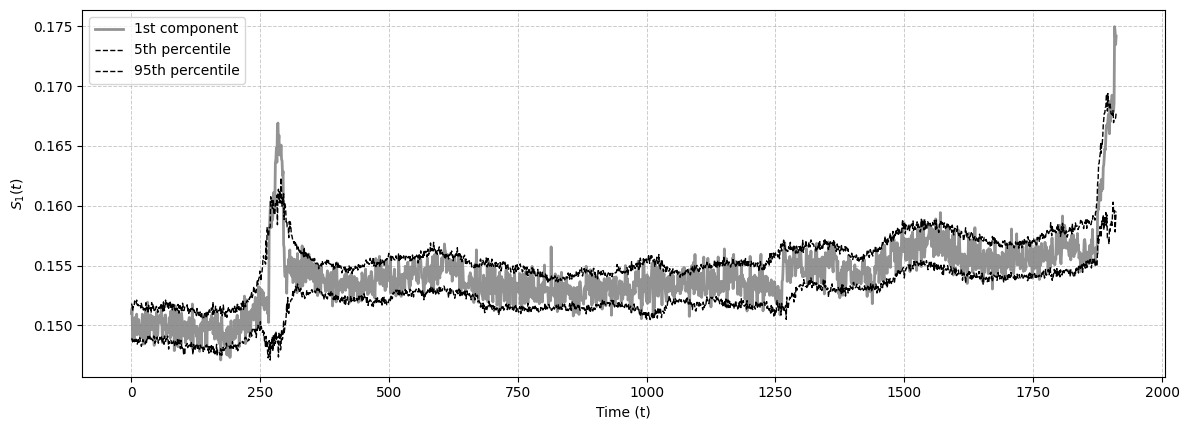

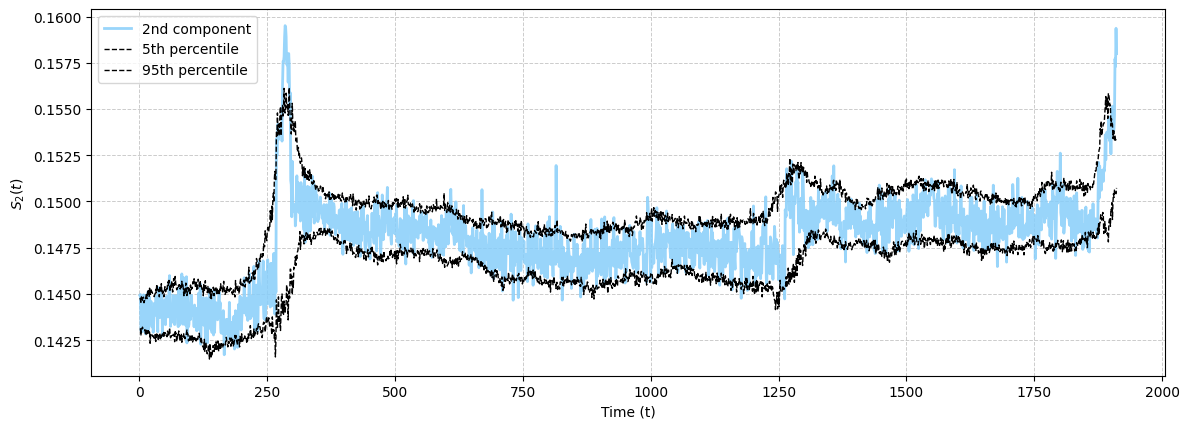

In [25]:
if real_est is not None and q05_real is not None and q95_real is not None:
    
    def plot_component(t, component, q05, q95, idx, color, label, ylabel):
        plt.figure(figsize=(12, 4.4))

        # main component
        plt.plot(
            t,
            component[:, idx],
            color=color,
            linewidth=2.0,
            alpha=0.85,
            label=label,
            zorder=2
        )

        # percentile bounds
        plt.plot(
            t,
            q05[:, idx],
            color="black",
            linestyle="--",
            linewidth=1.0,
            label="5th percentile",
            zorder=3
        )

        plt.plot(
            t,
            q95[:, idx],
            color="black",
            linestyle="--",
            linewidth=1.0,
            label="95th percentile",
            zorder=3
        )

        plt.xlabel("Time (t)")
        plt.ylabel(ylabel)

        plt.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.65
        )

        plt.legend(loc="upper left", frameon=True)
        plt.tight_layout()
        plt.show()

    plot_component(
        t=t_real,
        component=hi_real,
        q05=q05_real,
        q95=q95_real,
        idx=0,
        color="gray",
        label="1st component",
        ylabel=r"$S_1(t)$"
    )

    plot_component(
        t=t_real,
        component=hi_real,
        q05=q05_real,
        q95=q95_real,
        idx=1,
        color="lightskyblue",
        label="2nd component",
        ylabel=r"$S_2(t)$"
    )

else:
    print("Quantile-band plots skipped because simulated bands are not available.")

## **JAKIES WNIOSKI PO TYM WYZEJ I DOBRE RZECZY, NIE OD RAZU LIMITACJE**

### Discussion and limitations

The IMS real-data analysis extends the synthetic 2D pipeline to a real health-index signal. The RMS construction gives a two-dimensional HI for Bearing 1, and the reference-aligned trimming reproduces the preprocessing used in `references/dane_rzeczywiste.ipynb`.

Important limitations are:

- `tau_ref = [268, 1262, 1873]` are reference values unless MIDAST is available and actually executed in this workspace;
- the full MIDAST package is not currently present in the repository, so the notebook includes a TODO to add it;
- the reference notebook uses `start_index = 245`; the suspected offset near 252 is shown only as an alignment diagnostic;
- VAR(6) is estimated with the robust normalized-covariation approach implemented in this project, so it may differ from Rafal's exact helper functions;
- $\Sigma$ estimation can be unstable because it is fitted after trend estimation, scale estimation and VAR residual extraction;
- quantile-band coverage is an estimated value from our implementation, while 89.17% and 88.39% are reference values from Rafał's analysis.

Overall, this section should be read as a reproducible project-level real-data pipeline. Exact numerical equality with the reference notebook is not guaranteed unless the same MIDAST package, helper functions, preprocessing and simulation routines are included.


## Discussion, Limitations and Possible Extensions

The synthetic 1D and 2D experiments confirm that the implemented stochastic models can generate health-index trajectories with realistic degradation regimes and heavy-tailed random fluctuations. In Monte Carlo experiments the robust estimation pipeline recovers the main structural elements of the model: trend, scale, AR/VAR dependence and the stability index. The 2D study additionally shows that lagged dependence is captured by $\Theta$, while contemporaneous dependence belongs to the innovation matrix $\Sigma$.

The IMS real-data analysis shows how the same ideas transfer from controlled simulation to a bearing run-to-failure signal. RMS features from Bearing 1 form a two-dimensional health index, the initial warm-up part is removed according to Rafal's reference notebook, and VAR(6) residual modelling is used to assess the normalized stochastic component. Change points are treated carefully: unless MIDAST/ChangeDetector is actually available and executed, the notebook uses reference values rather than claiming a new detection result.

The main limitations are methodological and computational. Sigma estimation is sensitive to scale normalization, robust bootstrap diagnostics are expensive and therefore cached, and the real-data pipeline still depends on reference preprocessing decisions. Possible extensions include full MIDAST integration, Remaining Useful Life prediction, comparison with alternative heavy-tailed noise models, nonlinear or time-varying VAR dynamics, and validation on additional bearings or other historical HI datasets.
